In [1]:
library(asreml)
library(data.table)
library(tidyverse)
library(parallel)
library(qqman)
library(topGO)
library(pheatmap)
library(asremlPlus)
library(ggplot2)
library(ggridges)
library(ape)
library(ggtree)
library(geiger)
library(taxize)
library(xgboost)
library(PRROC)
library(glmnet)

Loading required package: Matrix



Online License checked out Wed Apr  9 10:24:05 2025


Loading ASReml-R version 4.2


── Attaching core tidyverse packages ───────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ─────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::between()     masks data.table::between()
✖ tidyr::expand()      masks Matrix::expand()
✖ dplyr::filter()      masks stats::filter()
✖ dplyr::first()       masks data.table::first()
✖ lubridate::hour()    masks data.table::hour()
✖ lubridate::isoweek() masks data.table::isoweek()
✖ dplyr::lag()         masks stats::lag()
✖ dplyr::last()        masks data.table::last()
✖ lubridate::mday()    masks data.table::mday()
✖ lubridate::minute()  masks data.table::minute()
✖ lubridate::month()   masks data.table::month()
✖ tidyr::pack()        masks Matrix::pack()
✖ lubridate

In [2]:
fit_model_v2 <- function(OG_id, data, Kmat,envDf,asmQual,responseVar) {
#   library(asreml)
    gc()
    asreml.options(verbose = FALSE)
    filtered_data <- subset(data, OG == OG_id)
    filtered_data <- filtered_data[,c("assemblyID",responseVar,"scaled.dn.ds","scaledScore", "scaledScore_DNA", "PMS",
                                      "compdup", "queryCov","pacbio")]
    missingTaxa <- setdiff(envDf$assemblyID, filtered_data$assemblyID)
    dfToAdd <- data.frame(assemblyID = missingTaxa,responseVar = envDf[missingTaxa,responseVar],
                          scaled.dn.ds = mean(filtered_data$scaled.dn.ds),
                          scaledScore = mean(filtered_data$scaledScore),
                          scaledScore_DNA = mean(filtered_data$scaledScore_DNA), PMS = 0,
                          compdup = rowSums(asmQual[missingTaxa,2:3]),queryCov = mean(filtered_data$queryCov),
                          pacbio = grepl("pacbio",asmQual[missingTaxa,6],ignore.case = T), PAV = 0)
    dfToAdd = na.omit(dfToAdd)
    filtered_data$PAV = 1
    colnames(dfToAdd) = colnames(filtered_data)
    filtered_data <- rbind(filtered_data,dfToAdd)
    filtered_data$PAV = as.factor(filtered_data$PAV)
    filtered_data$PMS = as.factor(filtered_data$PMS)
    filtered_data$pacbio = as.factor(filtered_data$pacbio)
    tmp = filtered_data
    fullFM = as.formula(paste0(responseVar, "~ PAV + PAV:scaled.dn.ds + PAV:scaledScore + PAV:scaledScore_DNA + PAV:PMS + compdup + PAV:queryCov + pacbio"))
    reducedFM = as.formula(paste0(responseVar, "~ compdup + queryCov + pacbio"))

    model_full <- asreml(fixed = fullFM,
                         random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)
    model_reduced1 <- asreml(fixed = fullFM,
                             ai.sing = F, data = filtered_data)
    filtered_data <- tmp
    model_reduced2 <- asreml(fixed = reducedFM,
                             random = ~ vm(assemblyID, Kmat) , ai.sing = F, data = filtered_data)  
    
    totalVar = var(filtered_data[,responseVar])
    modelSummary <- summary(model_full)
    IC_full = infoCriteria(model_full,IClikelihood = "full")
    IC_reduced = infoCriteria(model_reduced2,IClikelihood = "full")
    logLik_full <- IC_full$loglik
    logLik_reduced <- IC_reduced$loglik
    BIC_full <- IC_full$BIC
    BIC_reduced <- IC_reduced$BIC

    LRT_statistic <- -2 * (logLik_reduced - logLik_full)
    p_value <- pchisq(LRT_statistic, df = 5, lower.tail = FALSE)
    gene_explained <-  (model_reduced2$sigma2-model_full$sigma2)/totalVar
    phylo_explained <- (model_reduced1$sigma2-model_full$sigma2)/totalVar
  
    modelWald <- wald.asreml(model_full)
    partialCoeff <- model_full$coefficients$fixed[c(3,8,10,12,16)]
    partialPval <- modelWald[c(2,5:8),4]

#     return(model_full)
    out = c(OG_id,BIC_full,BIC_reduced,LRT_statistic,p_value,gene_explained,phylo_explained,totalVar,partialCoeff,partialPval)
    names(out) = c("OG","BIC_full","BIC_reduced","LR","p","geneVAE","phyloVAE","totalVar",
                   paste("partialCoeff",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"),
                   paste("partialP",c("PAV","dNdS","ESM2","plantCad","PMS"),sep = "_"))
    if(model_full$converge) return(out)
    else return(NULL)
}

In [3]:
metadata = read.csv("/workdir/sh2246/p_phyloGWAS/data/Poaceae_metadata_filtered_2025.04.07.csv",header = T)

In [4]:
phyloKMat <- read.table('/workdir/sh2246/p_phyloGWAS/output/phyloK_728Poaceae_astral_20250407.txt')
colnames(phyloKMat) <- rownames(phyloKMat)

In [5]:
envData = read.table("/workdir/sh2246/p_phyloGWAS/output/envData_759Poaceae_20240821.txt")

In [6]:
envDf = cbind(rownames(envData),envData)
colnames(envDf)[1] = "assemblyID"

In [7]:
envDf$assemblyID = as.factor(envDf$assemblyID)

In [8]:
# load tree
spTre = read.tree("/workdir/sh2246/p_phyloGWAS/output/PoaceaeTree_angiosperm353_astral_filtered_20250407.nwk")
spTre.rooted = root(spTre,"ASM1935983v1")
# spTre.rooted$edge.length[is.na(spTre.rooted$edge.length)] = 0.1

In [9]:
commonID = intersect(spTre.rooted$tip.label,rownames(envDf))
eTraits_filtered = as.data.frame(envDf[commonID,])
spTre.rooted.filtered = keep.tip(spTre.rooted,commonID)

In [10]:
testData_merged = data.table::fread("/workdir/sh2246/p_phyloGWAS/output/testData_merged.txt",header = T,data.table = F,nThread = 20)

In [11]:
testData_merged$PMS = as.factor(testData_merged$PMS)
testData_merged$assemblyID = as.factor(testData_merged$assemblyID)
testData_merged$pacbio = as.factor(testData_merged$pacbio)

In [12]:
OG_list = unique(testData_merged$OG)

In [15]:
#residual modeling

In [13]:
# calculate residuals
dat = merge(envDf,metadata,by = "assemblyID")
dat$compdup = dat$complete + dat$duplicated
rownames(dat) = dat$assemblyID
dat$pacbio = as.factor(grepl("pacbio",dat$technology,ignore.case = T))

In [14]:
R2phylo = c()
myY = c()
for (i in 1:10){
    myF1 = as.formula(paste0("envPC_", i, "~ compdup + pacbio"))
    myF2 = as.formula(paste0("envPC_", i, "~ 1"))
    model_Covariate <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat),
                              ai.sing = F, data = dat)

    myY = cbind(myY,model_Covariate$residuals)

    model_phylo <- asreml(fixed = myF2,random = ~ vm(assemblyID, phyloKMat),
                          ai.sing = F, data = dat)
    model_reduced <- asreml(fixed = myF2,
                          ai.sing = F, data = dat)
    R2phylo = c(R2phylo,(model_reduced$sigma2-model_phylo$sigma2)/model_reduced$sigma2) # pseudo-R², reduction-in-residual-variance R²

}


ASReml Version 4.2 08/04/2025 15:36:52
          LogLik        Sigma2     DF     wall
 1     -216.8686     0.6277925    703   15:36:52
 2     -200.1133     0.5875956    703   15:36:52
 3     -174.0031     0.5219674    703   15:36:52
 4     -143.7117     0.4392814    703   15:36:52
 5     -119.4515     0.3580598    703   15:36:53
 6     -110.0426     0.3083809    703   15:36:53
 7     -107.6811     0.2829078    703   15:36:53
 8     -107.2982     0.2723135    703   15:36:53
 9     -107.2550     0.2686859    703   15:36:53
10     -107.2510     0.2675776    703   15:36:53
11     -107.2507     0.2672540    703   15:36:53
ASReml Version 4.2 08/04/2025 15:36:53
          LogLik        Sigma2     DF     wall
 1     -212.4978     0.6400775    705   15:36:53
 2     -194.7232     0.5972440    705   15:36:54
 3     -167.0320     0.5278334    705   15:36:54
 4     -135.2804     0.4419674    705   15:36:54
 5     -110.1452     0.3588920    705   15:36:54
 6     -100.4205     0.3083113    705   15:3

Warning message in asreml(fixed = myF1, random = ~vm(assemblyID, phyloKMat), ai.sing = F, :
“Log-likelihood not converged”


ASReml Version 4.2 08/04/2025 15:37:13
          LogLik        Sigma2     DF     wall
 1     -346.8219     0.9369693    705   15:37:13
 2     -342.8583     0.9125459    705   15:37:13
 3     -337.6747     0.8734225    705   15:37:13
 4     -332.6908     0.8238590    705   15:37:13
 5     -327.8676     0.7607491    705   15:37:13
 6     -324.4202     0.7024494    705   15:37:13
 7     -322.4217     0.6564169    705   15:37:13
 8     -321.5117     0.6248161    705   15:37:14
 9     -321.1708     0.6052471    705   15:37:14
10     -321.0596     0.5939765    705   15:37:14
11     -321.0265     0.5877878    705   15:37:14
12     -321.0171     0.5844865    705   15:37:14
13     -321.0145     0.5827542    705   15:37:14


Warning message in asreml(fixed = myF2, random = ~vm(assemblyID, phyloKMat), ai.sing = F, :
“Log-likelihood not converged”


ASReml Version 4.2 08/04/2025 15:37:14
          LogLik        Sigma2     DF     wall
 1     -369.4250      1.039469    705   15:37:14
ASReml Version 4.2 08/04/2025 15:37:14
          LogLik        Sigma2     DF     wall
 1     -366.1950     0.9600986    703   15:37:14
 2     -365.3543     0.9483671    703   15:37:14
 3     -364.3384     0.9302750    703   15:37:15
 4     -363.5210     0.9061893    703   15:37:15
 5     -363.3306     0.8932940    703   15:37:15
 6     -363.3009     0.8879192    703   15:37:15
 7     -363.2973     0.8860007    703   15:37:15
 8     -363.2969     0.8853626    703   15:37:15
ASReml Version 4.2 08/04/2025 15:37:15
          LogLik        Sigma2     DF     wall
 1     -354.8258     0.9584876    705   15:37:15
 2     -353.9125     0.9464566    705   15:37:15
 3     -352.8239     0.9279864    705   15:37:16
 4     -351.9625     0.9035022    705   15:37:16
 5     -351.7663     0.8904839    705   15:37:16
 6     -351.7366     0.8851324    705   15:37:16
 7     

In [17]:
R2phylo

[1] 0.7233540 0.5390687 0.3778686 0.2672932 0.4907298 0.5011417 0.2486877
 [8] 0.4825242 0.4393731 0.1295752

In [19]:
# collapse X to one value per taxa
# tmp = mclapply(OG_list,function(x){
#     subTab = testData_merged[testData_merged$OG%in%x,]
#     idx1 = tapply(subTab$scaledScore ,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
#     idx2 = tapply(subTab$scaledScore_DNA,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
#     idx3 = tapply(subTab$PMS==1,subTab$assemblyID,function(a) max(as.numeric(a),na.rm = T))[commonID]
#     idx4 = tapply(subTab$scaled.dn.ds,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
#     idx5 = is.na(tapply(subTab$scaledScore,subTab$assemblyID,function(a) max(a,na.rm = T)))[commonID]
#     tmpOut = data.frame(ESM2 = as.numeric(idx1),
#                         PlantCad = as.numeric(idx2),
#                         PMS = as.numeric(idx3)*2-1,
#                         omega = as.numeric(idx4),
#                         PAV = as.numeric(idx5))
#     tmpOut[is.na(tmpOut)] = 0
#     colnames(tmpOut) = paste(x,colnames(tmpOut),sep = "_")
#     return(tmpOut)
# },mc.cores = 30)
# tmpMerged = Reduce("cbind",tmp)

In [14]:
myX = fread("/workdir/sh2246/p_phyloGWAS/output/functionPredictionPerOG_20250331.txt",data.table = F)

rownames(myX) = myX[,1]

myX = as.matrix(myX[,-1])

In [17]:
badSample = which(apply(myX,1,function(x) all(x==0)))

In [23]:
paste(sort(rownames(myX)[badSample]),collapse = " ")

[1] "AN20T018 AN20TSCR000210 AN21TNTL0089 AN21TNTL0090 AN21TNTL0095 AN21TNTL0118 AN21TNTL0169 AN21TNTL0346 AN21TS08 AN21TS35 AN21TS43 AN21TS53 AN21TS67 AN21TSTL0182 AN21TSTL0195 AN21TSTL0202 AN21TSTL0224 AN21TSTL0273 AN22TNTL080 AN22TNTL081 AN22TNTL085 AN22TNTL116 AN22TNTL144 AN22TNTL152 AN22TNTL160 AN22TNTL164 Dinebra_chinensis MCRTL001 MCRTL014 MCRTL016 OgluRS3 SRR17037945 SRR7121595 SRR7121923"

In [24]:
any(testData_merged$assemblyID%in%"AN20T018")

[1] FALSE

In [42]:
Dx = cov(t(myX),use = "complete")

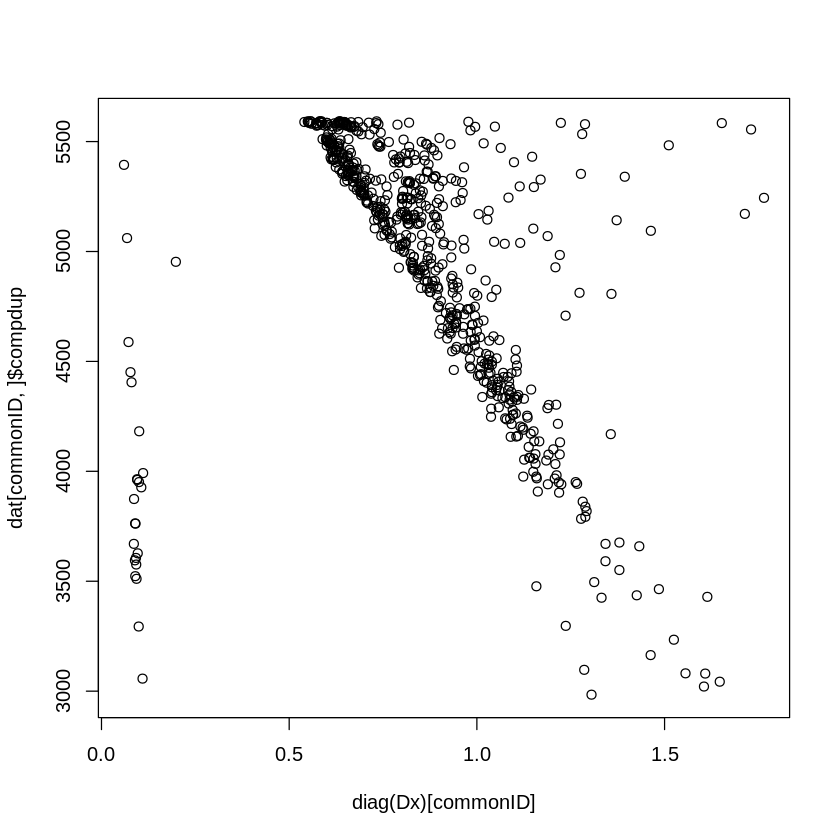

In [57]:
plot(diag(Dx)[commonID],dat[commonID,]$compdup)

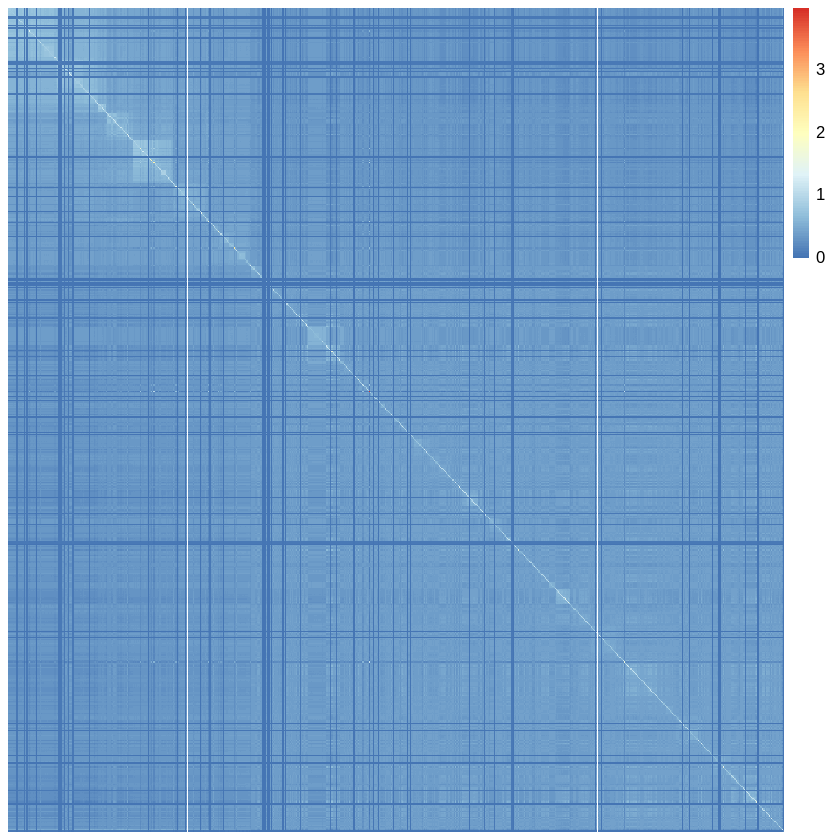

In [43]:
pheatmap(Dx[spTre.rooted.filtered$tip.label,spTre.rooted.filtered$tip.label],cluster_rows = F,cluster_cols = F,
         show_rownames = F,show_colnames = F)

In [44]:
Dx = Dx[-badSample,-badSample]

In [58]:
Dx = Dx[-which(diag(Dx)>2|diag(Dx)<0.2),-which(diag(Dx)>2|diag(Dx)<0.2)]

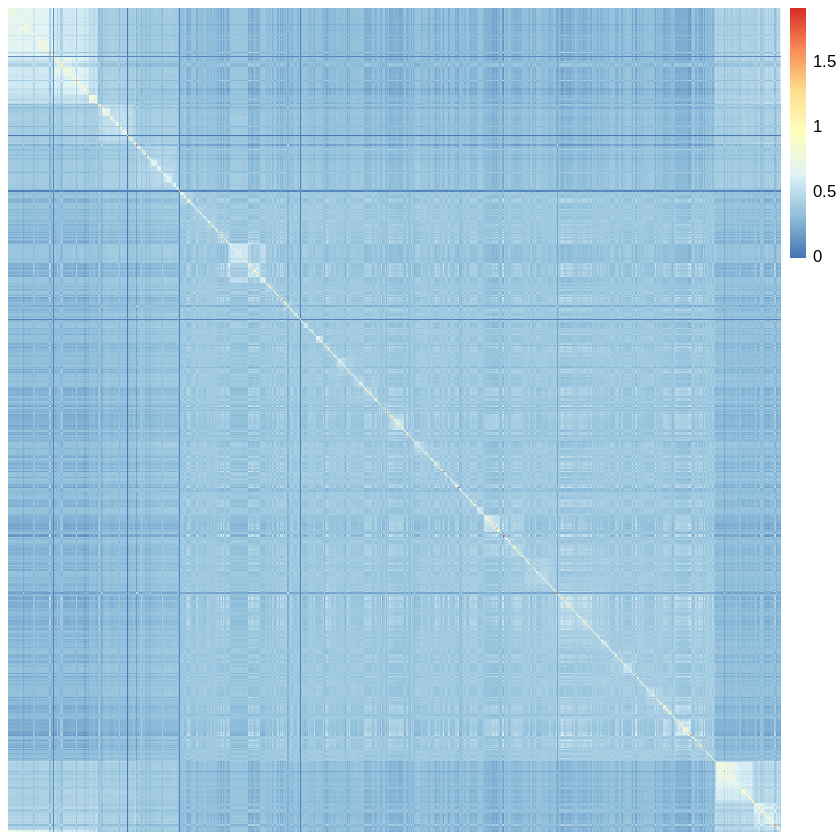

In [60]:
pheatmap(Dx,cluster_rows = F,cluster_cols = F,
         show_rownames = F,show_colnames = F)

In [41]:
setdiff(dat$assemblyID,rownames(Dx))

[1] "10wheat_assembly_jagger"              
  [2] "10wheat_assembly_lancer"              
  [3] "10wheat_assembly_stanley"             
  [4] "A17"                                  
  [5] "A42"                                  
  [6] "AANG_UGA4"                            
  [7] "Ab-Traiperm_572-DRAFT-PanAnd-1.0"     
  [8] "Ac-Pasquet1232-DRAFT-PanAnd-1.0"      
  [9] "Adlay_draft_genome_1.0"               
 [10] "Aegilops_cylindrica"                  
 [11] "aegilops_longissima_6782_assembly"    
 [12] "Aegilops_markgrafii"                  
 [13] "aegilops_sharonensis_1644_assembly"   
 [14] "aegilops_speltoides_cv_tivon"         
 [15] "Aegilops_triuncialis"                 
 [16] "Aet_v5.0"                             
 [17] "Ag-CAM1351-DRAFT-PanAnd-1.0"          
 [18] "Alloteropsis_cimicina"                
 [19] "Alomy_genome_v1"                      
 [20] "AN20T007"                             
 [21] "AN20T009"                             
 [22] "AN20T010"                             
 [23] "AN20T011"                             
 [24] "AN20T012"                             
 [25] "AN20T014"                             
 [26] "AN20T015"                             
 [27] "AN20T018"                             
 [28] "AN20T019"                             
 [29] "AN20T020"                             
 [30] "AN20T021"                             
 [31] "AN20T022"                             
 [32] "AN20T023"                             
 [33] "AN20T024"                             
 [34] "AN20T025"                             
 [35] "AN20T026"                             
 [36] "AN20T035"                             
 [37] "AN20T036"                             
 [38] "AN20T039"                             
 [39] "AN20T041"                             
 [40] "AN20T168"                             
 [41] "AN20T169"                             
 [42] "AN20T170"                             
 [43] "AN20T172"                             
 [44] "AN20T174"                             
 [45] "AN20T175"                             
 [46] "AN20T176"                             
 [47] "AN20T177"                             
 [48] "AN20T179"                             
 [49] "AN20T183"                             
 [50] "AN20T184"                             
 [51] "AN20T185"                             
 [52] "AN20T190"                             
 [53] "AN20T191"                             
 [54] "AN20T192"                             
 [55] "AN20T193"                             
 [56] "AN20T195"                             
 [57] "AN20T196"                             
 [58] "AN20TSCR000199"                       
 [59] "AN20TSCR000212"                       
 [60] "AN20TSCR000218"                       
 [61] "AN21TNTL0074"                         
 [62] "AN21TNTL0075"                         
 [63] "AN21TNTL0076"                         
 [64] "AN21TNTL0077"                         
 [65] "AN21TNTL0079"                         
 [66] "AN21TNTL0083"                         
 [67] "AN21TNTL0085"                         
 [68] "AN21TNTL0087"                         
 [69] "AN21TNTL0089"                         
 [70] "AN21TNTL0090"                         
 [71] "AN21TNTL0091"                         
 [72] "AN21TNTL0092"                         
 [73] "AN21TNTL0093"                         
 [74] "AN21TNTL0094"                         
 [75] "AN21TNTL0095"                         
 [76] "AN21TNTL0096"                         
 [77] "AN21TNTL0097"                         
 [78] "AN21TNTL0098"                         
 [79] "AN21TNTL0099"                         
 [80] "AN21TNTL0100"                         
 [81] "AN21TNTL0101"                         
 [82] "AN21TNTL0102"                         
 [83] "AN21TNTL0104"                         
 [84] "AN21TNTL0105"                         
 [85] "AN21TNTL0106"                         
 [86] "AN21TNTL0107"                         
 [87] "AN21TNTL0108"                         


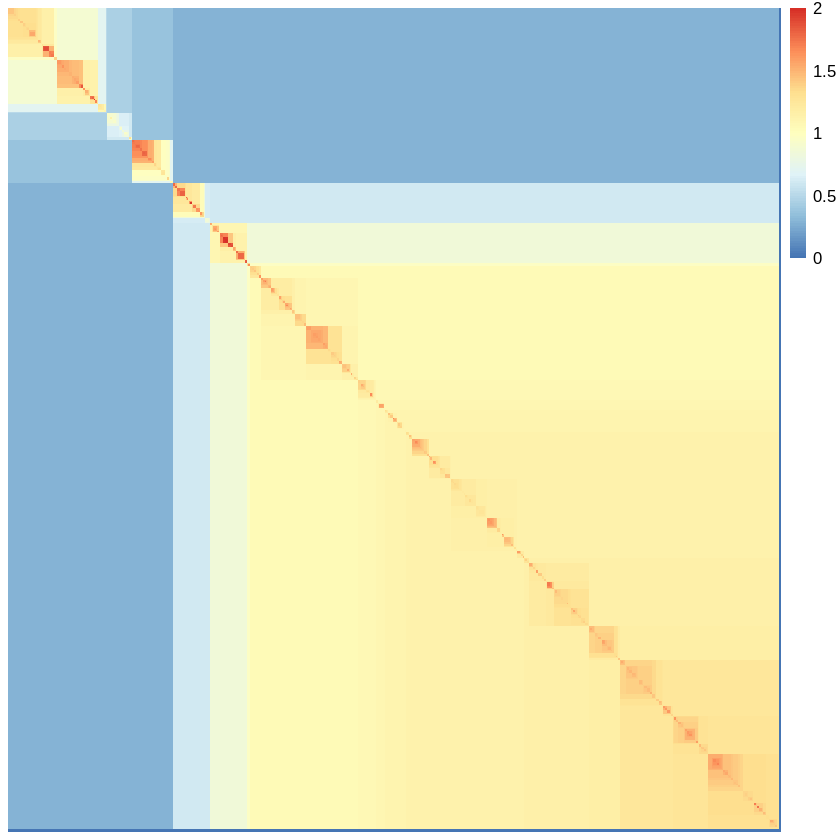

In [65]:
pheatmap(phyloKMat[spTre.rooted.filtered$tip.label,spTre.rooted.filtered$tip.label],cluster_rows = F,cluster_cols = F,
         show_rownames = F,show_colnames = F)

In [35]:
int.model <- asreml(fixed = envPC_1 ~ compdup + pacbio,random = ~ vm(assemblyID, Dx) + vm(assemblyID, phyloKMat),
                    ai.sing = F, data = dat,start.value = T)

intV = int.model$vparameters.table

Warning message:
“assemblyID has levels in the data that are missing in Dx”
Warning message:
“assemblyID has levels in the data that are missing in Dx”


In [48]:
intV[,2] = c(0.4,0.4,0.2)

In [49]:
# intV[,3] = c("P","U","U")

In [50]:
intV

Component,Value,Constraint
<chr>,<dbl>,<chr>
"vm(assemblyID, Dx)",0.4,P
"vm(assemblyID, phyloKMat)",0.4,P
units!R,0.2,P


In [ ]:
asreml.options(maxit = 60,verbose = F)
myF1 = as.formula(paste0("envPC_", 1, "~ compdup + pacbio"))
model1 <- asreml(fixed = myF1,random = ~ vm(assemblyID, Dx) + vm(assemblyID, phyloKMat),#G.param = intV,
                ai.sing = T, data = dat)
model2 <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat) + vm(assemblyID, Dx) ,#G.param = intV,
                ai.sing = T, data = dat)

In [75]:
summary(model1)$varcomp
summary(model2)$varcomp

,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"ide(assemblyID, Dx)",4.847738e+00,2053.2987827,0.002360951,?,93.7
"vm(assemblyID, phyloKMat)",2.014064e+01,8531.2309481,0.002360813,?,93.7
units!R,2.624777e-04,0.1186875,0.002211503,P,0.0


,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"ide(assemblyID, Dx)",5.002187e-08,NA,NA,B,NA
"vm(assemblyID, phyloKMat)",7.803327e-01,0.1603444,4.866605,P,0.2
units!R,4.943220e-01,0.0317567,15.565914,P,0.0


In [ ]:
asreml.options(maxit = 60,verbose = F)
varComp = list()
VAE = c()
for (i in 1:5){
    myF1 = as.formula(paste0("envPC_", i, "~ compdup + pacbio"))
    model <- asreml(fixed = myF1,random = ~ vm(assemblyID, phyloKMat) + vm(assemblyID, Dx),#G.param = intV,
                    ai.sing = T, data = dat)
    varComp[[i]] = summary(model)$varcomp
    VAE = rbind(VAE,summary(model)$varcomp$component/sum(summary(model)$varcomp$component))
}


Warning message:
“assemblyID has levels in the data that are missing in Dx”
Warning message:
“assemblyID has levels in the data that are missing in Dx”


In [49]:
varComp

,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"vm(assemblyID, Dx, ""PSD"")",0.6283059,0.10353834,6.068341,P,0.1
"vm(assemblyID, phyloKMat)",0.4003010,0.11524235,3.473559,P,0.3
units!R,0.2580465,0.03016033,8.555827,P,0.0
,component,std.error,z.ratio,bound,%ch
,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
"vm(assemblyID, Dx, ""PSD"")",0.9334723,0.16317961,5.720520,P,0.1
"vm(assemblyID, phyloKMat)",0.3825303,0.12822845,2.983194,P,0.2
units!R,0.3797201,0.04727075,8.032876,P,0.0
,component,std.error,z.ratio,bound,%ch


In [50]:
VAE

0.4883257,0.3111180,0.2005564
0.5504864,0.2255854,0.2239282
0.4757135,0.1928999,0.3313866
0.6332168,0.1866919,0.1800913
0.4087258,0.2809641,0.3103100


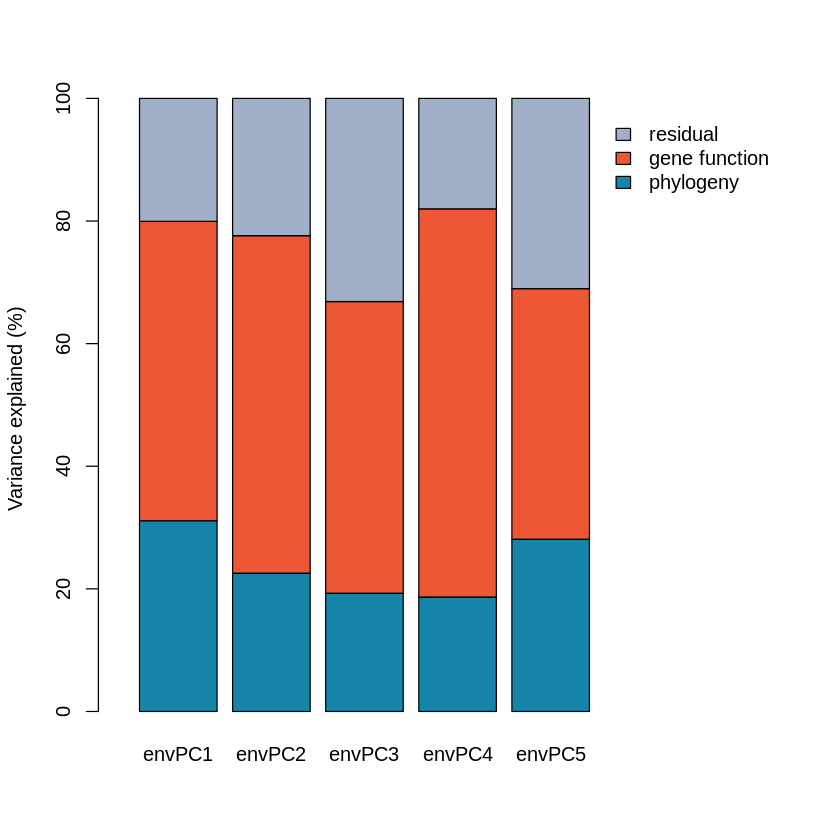

In [51]:
barplot(t(VAE[1:5,c(2,1,3)])*100,names.arg = paste0("envPC",1:5),col = c("#1685a9","#ed5736","#a1afc9"),
        legend.text = c("phylogeny","gene function","residual"),xlim = c(0,8.25),args.legend = list(bty = 'n'),
        ylab = "Variance explained (%)")

In [28]:
# genomic features model

aa.comp = read.table("/workdir/sh2246/p_phyloGWAS/output/poaceae_aaComposition_20250312.txt",row.names =1,header = T)

gcContent = read.table("/workdir/sh2246/p_phyloGWAS/data/formatted_allGC_perCDS.txt",header = T)

gcVec = gcContent$GC...

names(gcVec) = gsub("\\.fa","",gcContent$file)

In [29]:
set.seed(666)
tmpX = cbind(as.matrix(aa.comp[commonID,]),gcVec[commonID])
cv_fit <- cv.glmnet(tmpX, myY[,1], alpha = 0)
best_lambda <- cv_fit$lambda.min
best_ridge_gF <- glmnet(tmpX, myY[,1], alpha = 0, lambda = best_lambda)
y_hat = predict(best_ridge_gF, s = best_lambda, newx = tmpX)
R2gF = 1-sum((myY[,1]-y_hat)^2)/sum((myY[,1]-mean(myY[,1]))^2)
R2gF

cv_fit <- cv.glmnet(myX, myY[,1], alpha = 0)
best_lambda <- cv_fit$lambda.min
best_ridge_func <- glmnet(myX, myY[,1], alpha = 0, lambda = best_lambda)
y_hat = predict(best_ridge_func, s = best_lambda, newx = myX)
R2func = 1-sum((myY[,1]-y_hat)^2)/sum((myY[,1]-mean(myY[,1]))^2)
R2func

cv_fit <- cv.glmnet(cbind(tmpX,myX), myY[,1], alpha = 0)
best_lambda <- cv_fit$lambda.min
best_ridge_full <- glmnet(cbind(tmpX,myX), myY[,1], alpha = 0, lambda = best_lambda)
y_hat = predict(best_ridge_full, s = best_lambda, newx = cbind(tmpX,myX))
R2full = 1-sum((myY[,1]-y_hat)^2)/sum((myY[,1]-mean(myY[,1]))^2)
R2full

R2full-R2func
R2full-R2gF

[1] 0.01266275

[1] 0.4532121

[1] 0.4532265

[1] 1.439638e-05

[1] 0.4405637

In [33]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22460709,1199.6,40652468,2171.1,40652468,2171.1
Vcells,6821336401,52042.7,11098539084,84675.2,11098539084,84675.2


In [32]:
set.seed(666)
R2FuncVec = c()
R2gFVec = c()
for (i in 1:5){
    gc()
    tmpX = cbind(as.matrix(aa.comp[commonID,]),gcVec[commonID])
    cv_fit <- cv.glmnet(tmpX, myY[,i], alpha = 0)
    best_lambda <- cv_fit$lambda.min
    best_ridge_gF <- glmnet(tmpX, myY[,i], alpha = 0, lambda = best_lambda)
    y_hat = predict(best_ridge_gF, s = best_lambda, newx = tmpX)
    R2gF = 1-sum((myY[,i]-y_hat)^2)/sum((myY[,i]-mean(myY[,i]))^2)
    R2gF

    cv_fit <- cv.glmnet(myX, myY[,i], alpha = 0)
    best_lambda <- cv_fit$lambda.min
    best_ridge_func <- glmnet(myX, myY[,i], alpha = 0, lambda = best_lambda)
    y_hat = predict(best_ridge_func, s = best_lambda, newx = myX)
    R2func = 1-sum((myY[,i]-y_hat)^2)/sum((myY[,i]-mean(myY[,i]))^2)
    R2func

    cv_fit <- cv.glmnet(cbind(tmpX,myX), myY[,i], alpha = 0)
    best_lambda <- cv_fit$lambda.min
    best_ridge_full <- glmnet(cbind(tmpX,myX), myY[,i], alpha = 0, lambda = best_lambda)
    y_hat = predict(best_ridge_full, s = best_lambda, newx = cbind(tmpX,myX))
    R2full = 1-sum((myY[,i]-y_hat)^2)/sum((myY[,i]-mean(myY[,i]))^2)
    R2full

    R2FuncVec = c(R2FuncVec,R2full-R2gF)
    R2gFVec = c(R2gFVec,R2full-R2func)
}


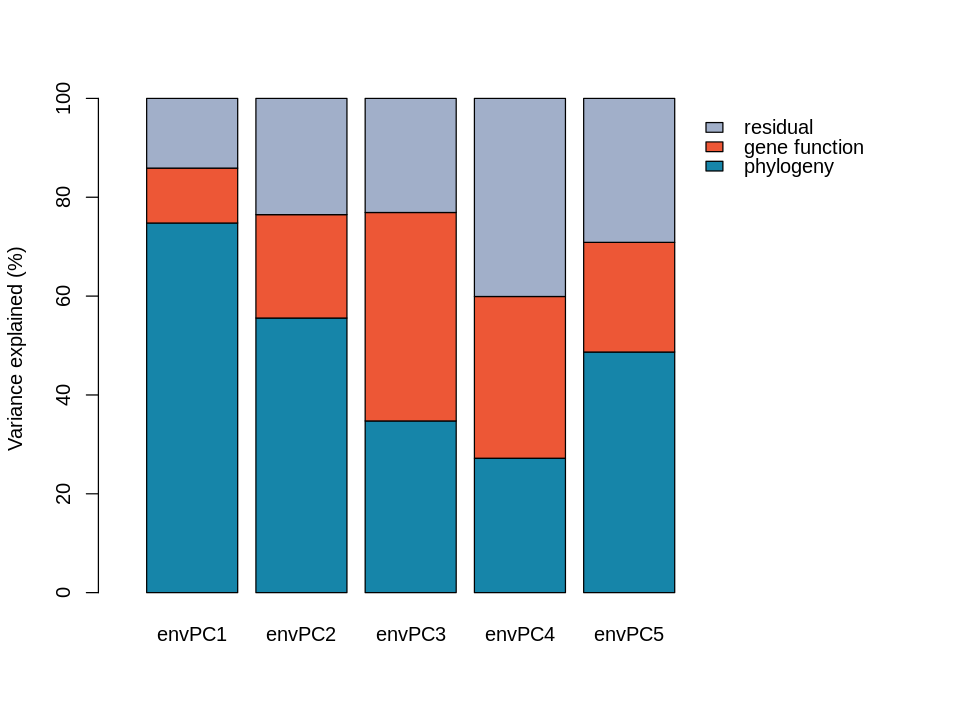

In [39]:
tmp = rbind(R2phylo,R2FuncVec*(1-R2phylo))
tmp = rbind(tmp,1-colSums(tmp))*100
options(repr.plot.width=8, repr.plot.height=6)
barplot(tmp[,1:5],names.arg = paste0("envPC",1:5),col = c("#1685a9","#ed5736","#a1afc9"),
        legend.text = c("phylogeny","gene function","residual"),xlim = c(0,8.25),args.legend = list(bty = 'n'),
        ylab = "Variance explained (%)")

In [35]:
R2gFVec*(1-R2phylo)

[1]  3.629040e-06  2.286363e-05 -1.839736e-02  1.551574e-02  1.256384e-05
 [6]  7.622374e-06  3.936471e-05 -1.431788e-02  1.548208e-02  2.113038e-05

In [ ]:
#### prediction task ####

In [92]:
set.seed(1234)
folds <- split(sample(1:nrow(myY)), ceiling(seq_along(1:nrow(myY)) / (nrow(myY)/ 10)))

In [ ]:
set.seed(1234)
r = c()
predY = c()
for (j in 1:5){
    r_tmp = c()
    predY_tmp = c()
    for (i in 1:10){
        trainIdx = setdiff(1:nrow(myY),folds[[i]])
        cv_fit <- cv.glmnet(myX[trainIdx,], myY[trainIdx,j], alpha = 0)
        best_lambda <- cv_fit$lambda.min
        best_ridge <- glmnet(myX[trainIdx,], myY[trainIdx,j], alpha = 0, lambda = best_lambda)
        y_hat = predict(best_ridge, s = best_lambda, newx = myX[-trainIdx,])
        predY_tmp[sort(folds[[i]])] = y_hat
        r_tmp = c(r_tmp,cor(y_hat,myY[-trainIdx,j]))
    }
    predY = cbind(predY,predY_tmp)
    r = cbind(r,r_tmp)
    gc()
}


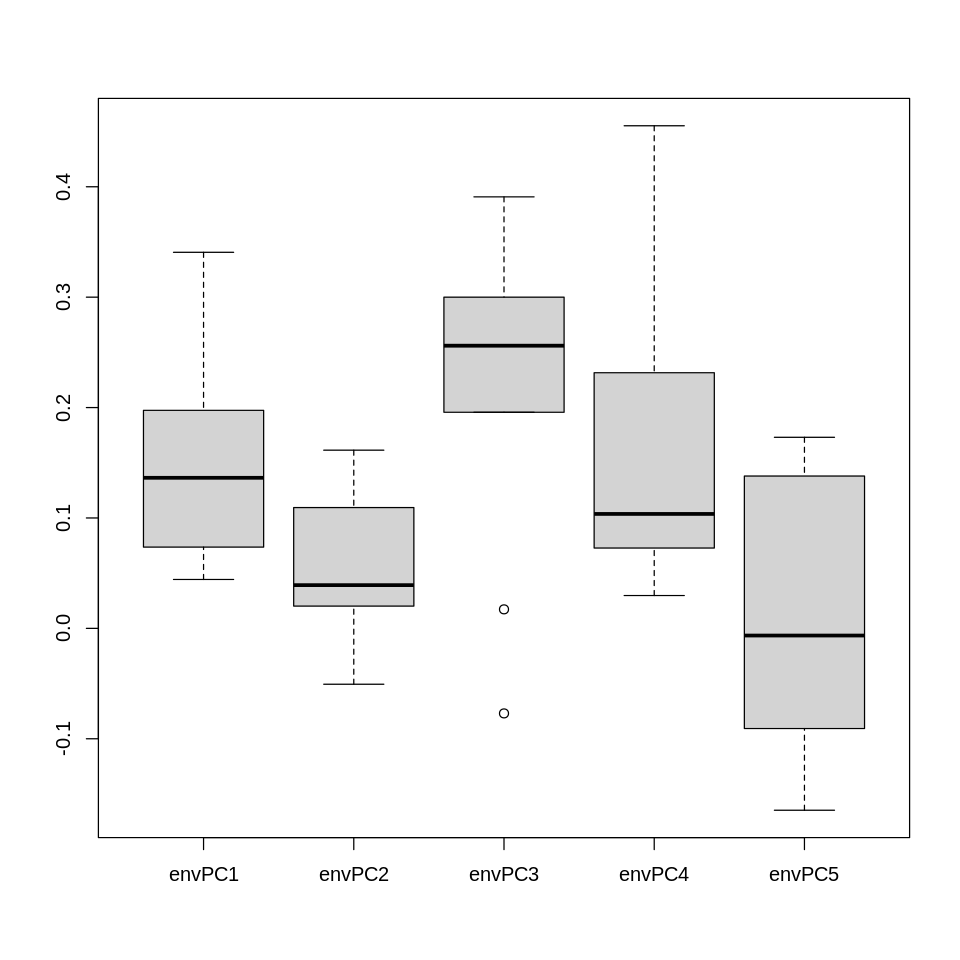

In [109]:
options(repr.plot.width=8, repr.plot.height=8)
boxplot(r,names = paste0("envPC",1:5))

In [110]:
GO_CC = fread("/workdir/sh2246/p_phyloGWAS_archived/output/deepGO_poaceaeHelixerOG/poaceaeHelixerOG_ancSeq_gapRemoved_v2_uppercase_output_CC_f.gmt",data.table = F,fill = T,header = F)

In [112]:
library(dplyr)
library(tidyr)

GO_CC <- GO_CC %>%
  unite("OGs", V3:ncol(GO_CC), sep = ",", na.rm = TRUE)

In [118]:
GO_CC_filtered = GO_CC[GO_CC$V2 %in% c("extracellular region","chloroplast","mitochondrion","nucleus",
                                       "plasma membrane","cell wall","ribosome","Golgi apparatus",
                                       "vacuole","endoplasmic reticulum","vesicle"),]

In [119]:
head(GO_CC_filtered)

V1         V2                  
2  GO:0005576 extracellular region
10 GO:0005634 nucleus             
11 GO:0005739 mitochondrion       
13 GO:0005886 plasma membrane     
17 GO:0005773 vacuole             
25 GO:0005840 ribosome            
   OGs                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                        

In [58]:
library(UpSetR)

In [120]:
testGene = lapply(GO_CC_filtered[,3],function(x) unique(as.vector(limma::strsplit2(x,","))))
names(testGene) = GO_CC_filtered[,2]

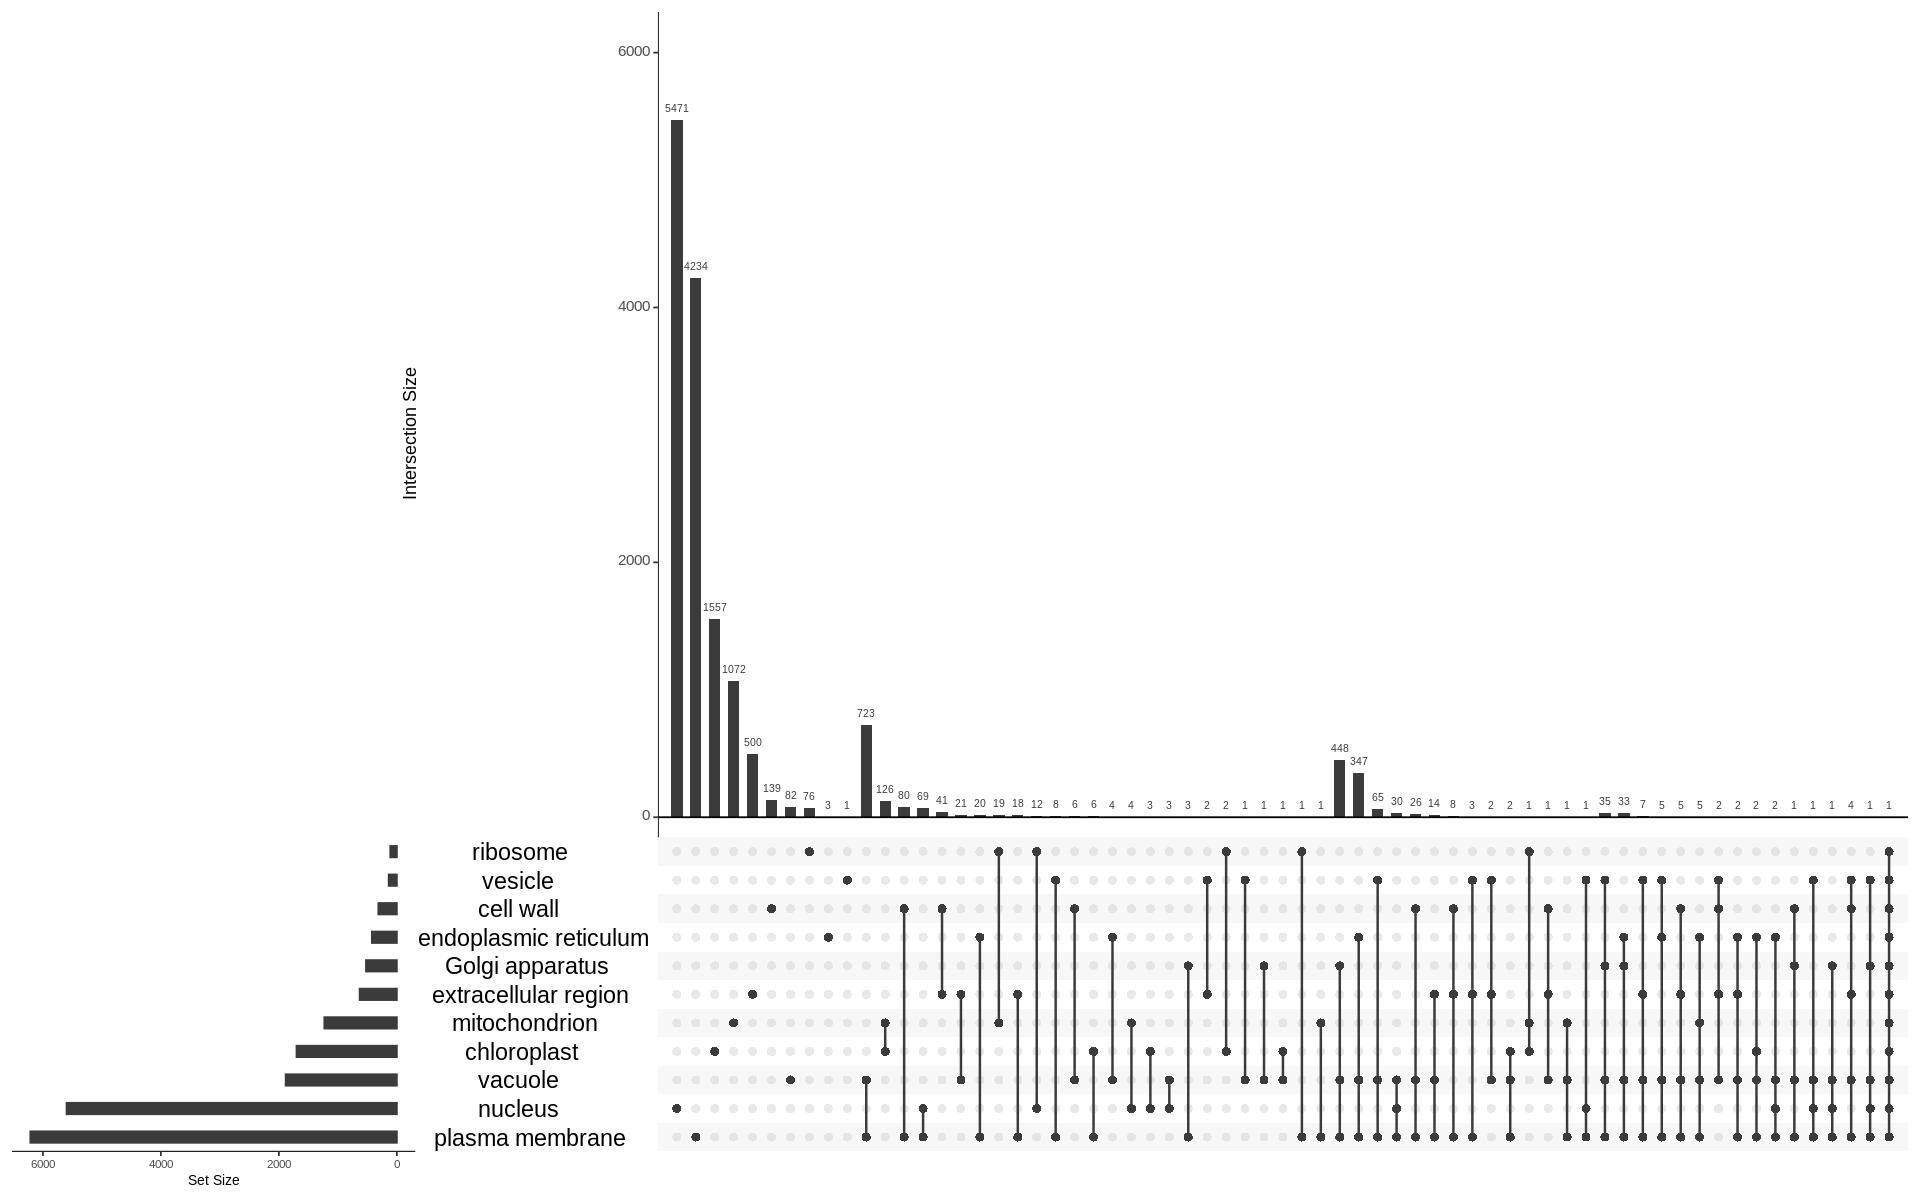

In [121]:
options(repr.plot.width=16, repr.plot.height=10)
upset(fromList(testGene), text.scale = c(1.3, 1.3, 1, 1, 2, 1),nsets = 12,nintersects = 100)

In [117]:
length(unique(as.vector(testGene$nucleus)))

[1] 5599

In [145]:
set.seed(123)
r_CC = c()
predY_CC = c()
for (j in 1:11){
    r_tmp = c()
    predY_tmp = c()
    subOG = limma::strsplit2(colnames(myX),"_")[,2]%in%testGene[[j]]
    subOG_random = limma::strsplit2(colnames(myX),"_")[,2]%in%sample(setdiff(OG_list,testGene[[j]]),length(testGene[[j]]))
    for (i in 1:10){
        trainIdx = setdiff(1:nrow(myY),folds[[i]])
        cv_fit <- cv.glmnet(myX[trainIdx,subOG], myY[trainIdx,1], alpha = 0)
        best_lambda <- cv_fit$lambda.min
        best_ridge <- glmnet(myX[trainIdx,subOG], myY[trainIdx,1], alpha = 0, lambda = best_lambda)
        y_hat = predict(best_ridge, s = best_lambda, newx = myX[-trainIdx,subOG])
        predY_tmp[sort(folds[[i]])] = y_hat
        r_tmp = c(r_tmp,cor(y_hat,myY[-trainIdx,1]))
    }
    for (i in 1:10){
        trainIdx = setdiff(1:nrow(myY),folds[[i]])
        cv_fit <- cv.glmnet(myX[trainIdx,subOG_random], myY[trainIdx,1], alpha = 0)
        best_lambda <- cv_fit$lambda.min
        best_ridge <- glmnet(myX[trainIdx,subOG_random], myY[trainIdx,1], alpha = 0, lambda = best_lambda)
        y_hat = predict(best_ridge, s = best_lambda, newx = myX[-trainIdx,subOG_random])
        predY_tmp[sort(folds[[i]])] = y_hat
        r_tmp = c(r_tmp,cor(y_hat,myY[-trainIdx,1]))
    }
    predY_CC = cbind(predY_CC,predY_tmp)
    r_CC = cbind(r_CC,r_tmp)
    gc()
}


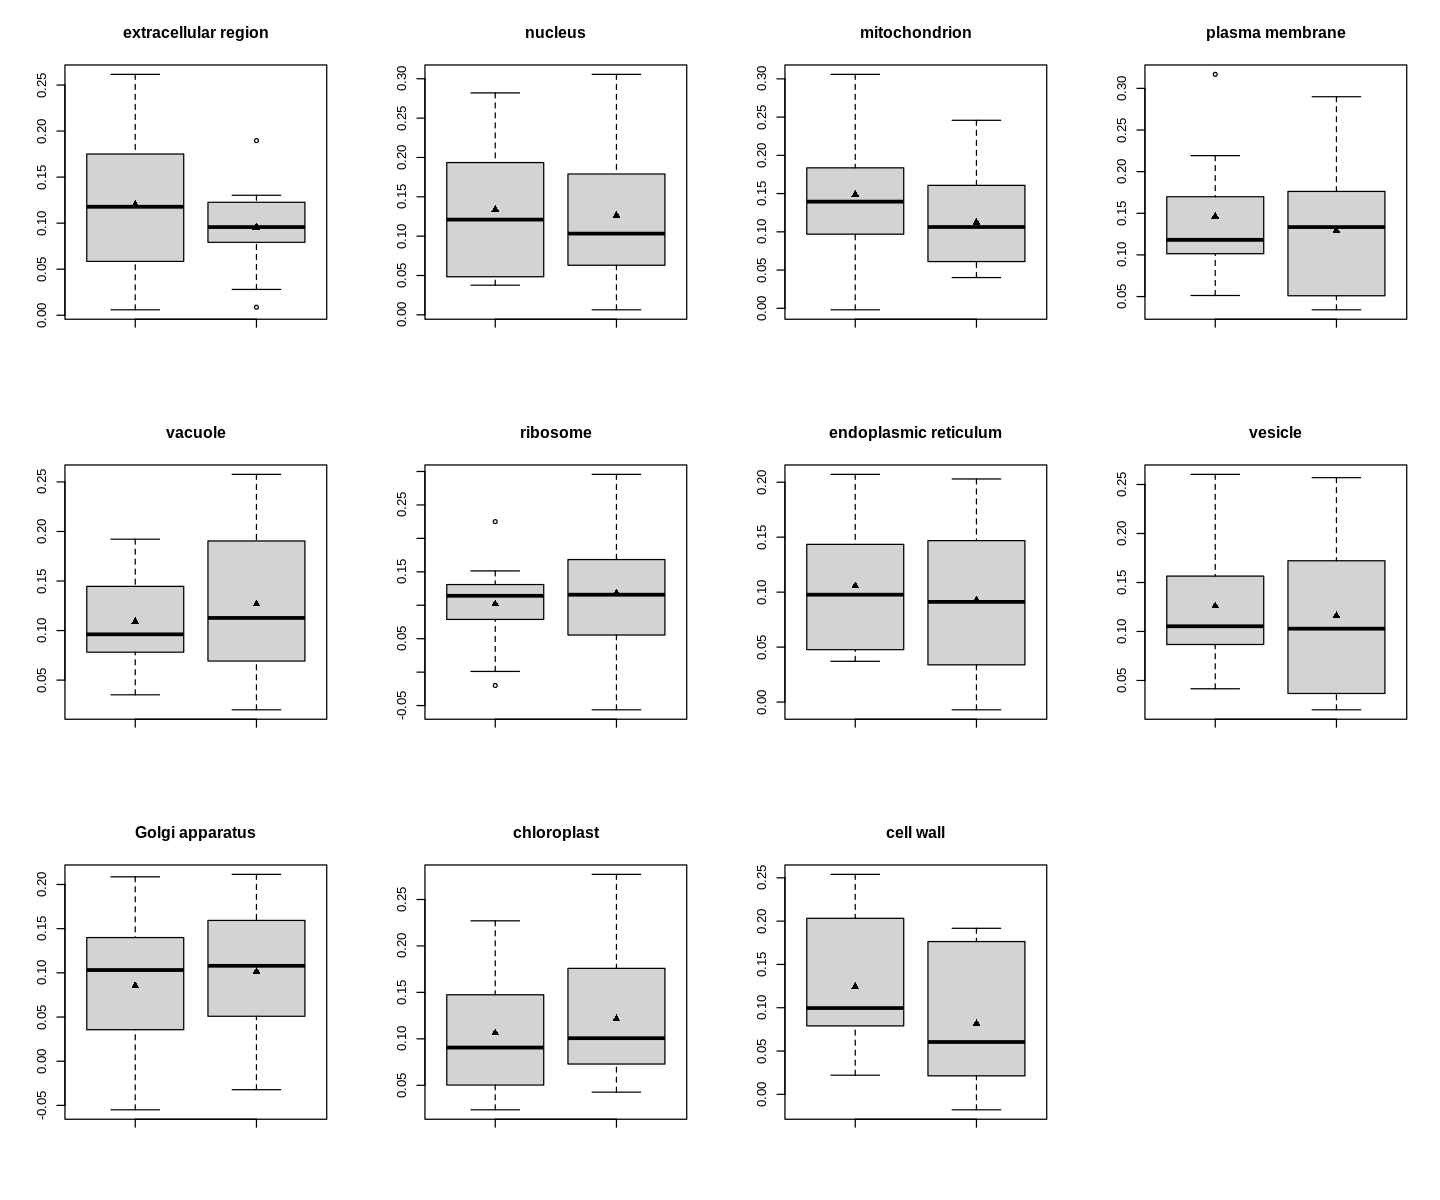

In [152]:
options(repr.plot.width=12, repr.plot.height=10)
par(mfrow = c(3,4))
for (i in 1:11){
    boxplot(r_CC[1:10,i],r_CC[11:20,i],main = names(testGene)[i])
    points(1:2,tapply(r_CC[,i],gl(2,10),mean),pch = 17)
}


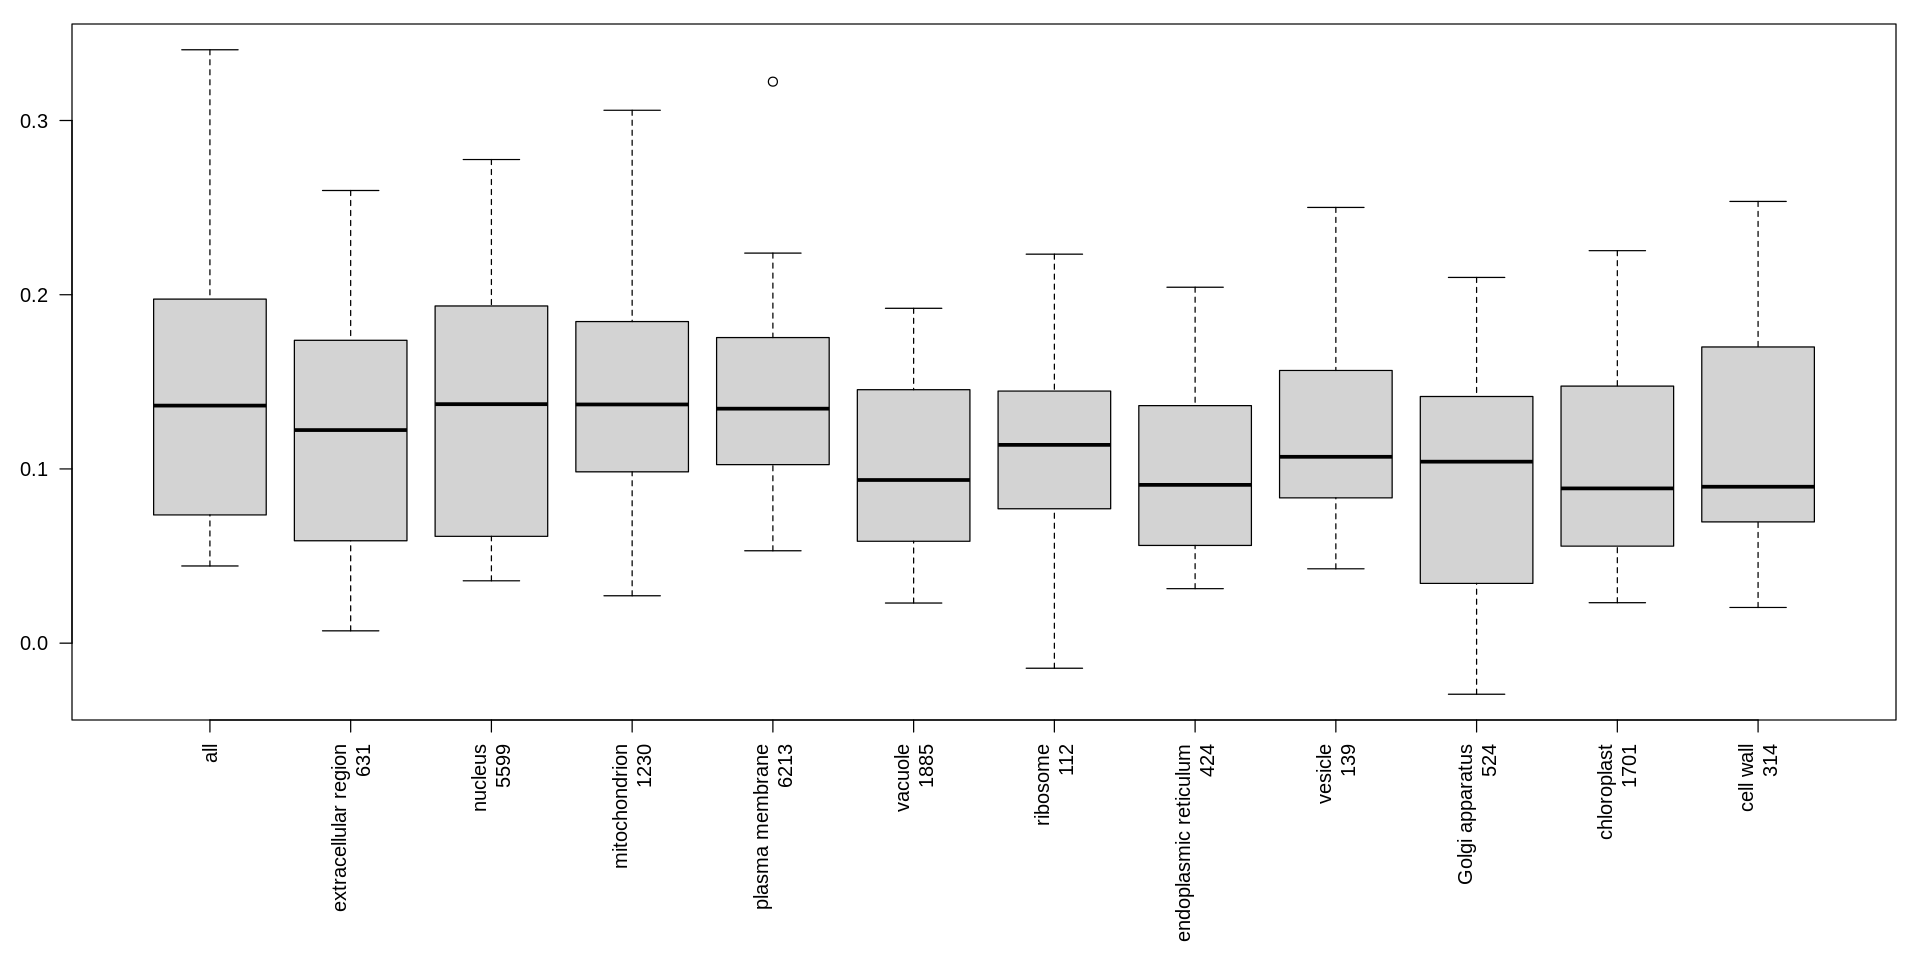

In [130]:
options(repr.plot.width=16, repr.plot.height=8)
par(mar = c(10,3,1,1))
boxplot(cbind(r[,1],r_CC[,-(1:12)]),names = c("all",paste(names(testGene),sapply(testGene,length),sep = "\n")),las = 2)

In [407]:
r_lasso = c()
predY_lasso = c()
for (j in 1:5){
    r_tmp = c()
    predY_tmp = c()
    for (i in 1:10){
        trainIdx = setdiff(1:nrow(myY),folds[[i]])
        cv_fit <- cv.glmnet(myX[trainIdx,], myY[trainIdx,j], alpha = 1)
        best_lambda <- cv_fit$lambda.min
        best_ridge <- glmnet(myX[trainIdx,], myY[trainIdx,j], alpha = 1, lambda = best_lambda)
        y_hat = predict(best_ridge, s = best_lambda, newx = myX[-trainIdx,])
        predY_tmp[sort(folds[[i]])] = y_hat
        r_tmp = c(r_tmp,cor(y_hat,myY[-trainIdx,j]))
    }
    predY_lasso = cbind(predY_lasso,predY_tmp)
    r_lasso = cbind(r_lasso,r_tmp)
}


Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”
Warning message in cor(y_hat, myY[-trainIdx, j]):
“the standard deviation is zero”


In [183]:
set.seed(123)
androIdx = sample(which(taxanomicGroup[commonID,5]%in%"Andropogoneae"))
folds_andro <- split(androIdx, ceiling(seq_along(androIdx) / (length(androIdx)/ 10)))

In [184]:
r_andro = c()
predY_andro = c()
for (i in 1:10){
    trainIdx = setdiff(sort(androIdx),folds_andro[[i]])
    cv_fit <- cv.glmnet(myX[trainIdx,], myY[trainIdx,], alpha = 0)
    best_lambda <- cv_fit$lambda.min
    best_ridge <- glmnet(myX[trainIdx,], myY[trainIdx,], alpha = 0, lambda = best_lambda)
    y_hat = predict(best_ridge, s = best_lambda, newx = myX[folds_andro[[i]],])
    predY_andro[folds_andro[[i]]] = y_hat
    r_andro = c(r_andro,cor(y_hat,myY[folds_andro[[i]],]))
}

In [174]:
library(BGLR)

In [193]:
r_bayesC = c()
predY_bayesC = c()
for (i in 1:10){
    tmpY = myY
    tmpY[folds[[i]]] = NA
    fmBC=BGLR(y=tmpY,ETA=list( list(X=myX,model='BayesC')),nIter=5000,burnIn=1000,
          saveAt="/workdir/sh2246/p_phyloGWAS/output/tmp/",verbose = F, rmExistingFiles = T)
    y_hat = predict(fmBC)[folds[[i]]]
    predY_bayesC[folds[[i]]] = y_hat
    r_bayesC = c(r_bayesC,cor(y_hat,myY[folds[[i]],]))
}


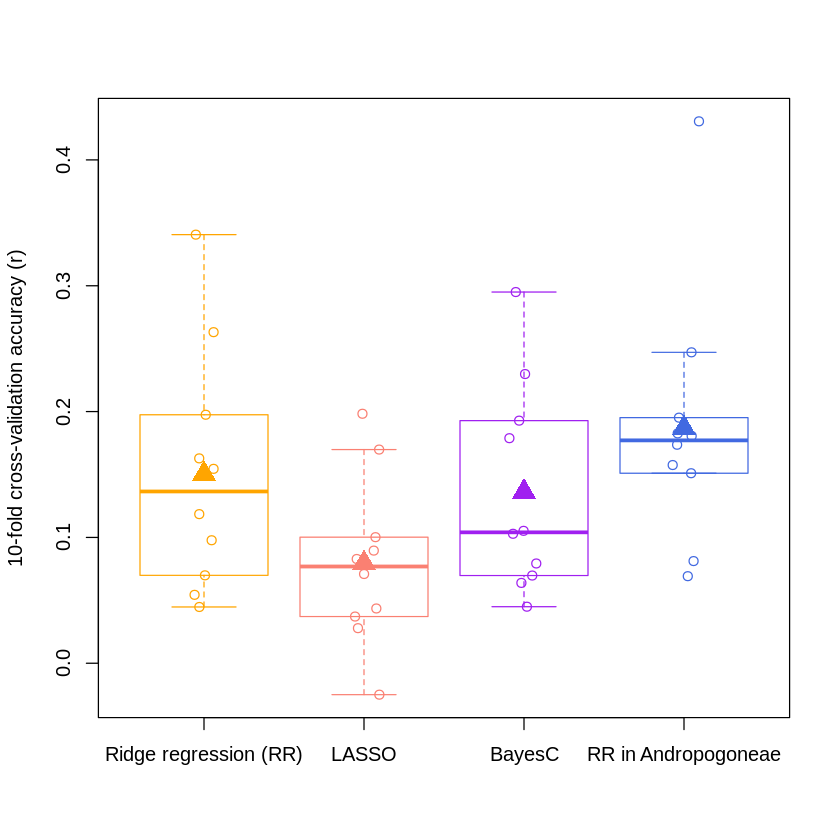

In [243]:
boxplot(r,r_lasso,r_bayesC,r_andro,ylab = "10-fold cross-validation accuracy (r)", 
        names = c("Ridge regression (RR)","LASSO","BayesC","RR in Andropogoneae"),
        col = NA, border = c("orange","salmon","purple","royalblue"),pch = "")
points(rep(1:4,each = 10)+runif(40,-0.1,0.1),c(r,r_lasso,r_bayesC,r_andro),
       col = rep(c("orange","salmon","purple","royalblue"),each = 10))
points(1:4,c(mean(r),mean(r_lasso,na.rm = T),mean(r_bayesC),mean(r_andro)),
       col = c("orange","salmon","purple","royalblue"), pch = 17, cex = 2)

In [286]:
PCA.aa.comp = prcomp(aa.comp[commonID,])

options(repr.plot.width=6, repr.plot.height=6)
plot(1:20,PCA.aa.comp$sdev^2/sum(PCA.aa.comp$sdev^2),xlab = "envPCs",ylab = "Variance explained")
sum((PCA.aa.comp$sdev^2/sum(PCA.aa.comp$sdev^2))[1:3])

In [329]:
r_aa = c()
predY_aa = c()
tmpX = cbind(as.matrix(aa.comp[commonID,]),gcVec[commonID])
for (i in 1:10){
    trainIdx = setdiff(1:nrow(myY),folds[[i]])
    cv_fit <- cv.glmnet(tmpX[-folds[[i]],], myY[-folds[[i]],], alpha = 0)
    best_lambda <- cv_fit$lambda.min
    best_ridge <- glmnet(tmpX[-folds[[i]],], myY[-folds[[i]],], alpha = 0, lambda = best_lambda)
    y_hat = predict(best_ridge, s = best_lambda, newx = tmpX[folds[[i]],])
    predY_aa[folds[[i]]] = y_hat
    r_aa = c(r_aa,cor(y_hat,myY[-trainIdx,]))
}



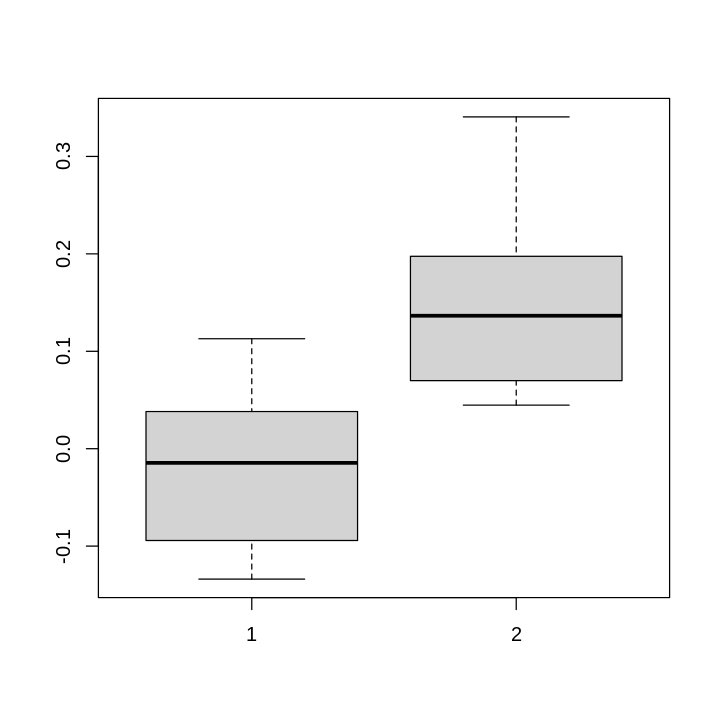

In [337]:
boxplot(r_aa,r)

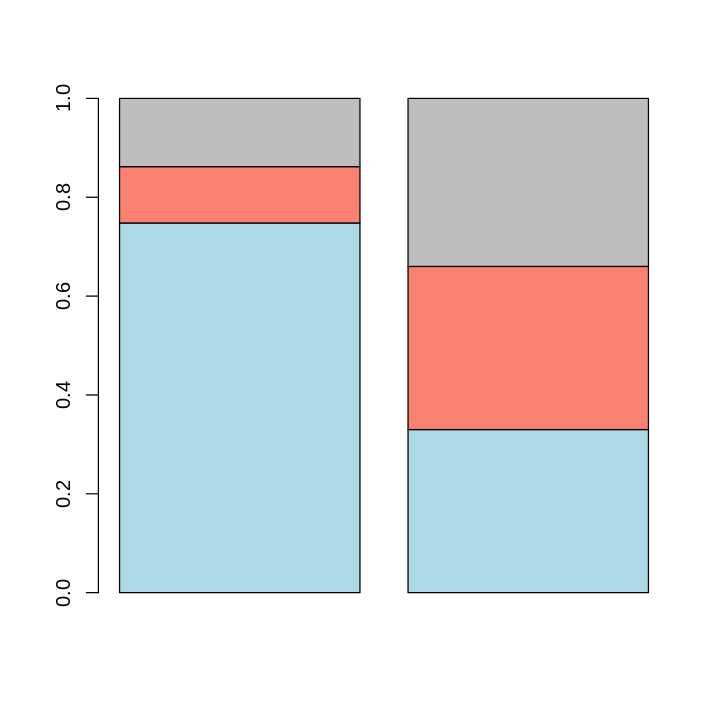

In [360]:
barplot(cbind(c(0.748,0.114,0.138),c(0.33,0.33,0.34)),beside = F,col = c("lightblue","salmon","grey"))

In [24]:
assemblyID_subset = commonID[!taxanomicGroup[commonID,7]%in%c("Rhytachninae","Tripsacinae","Rottboelliinae")]
testData_subset = subset(testData_merged,assemblyID%in%assemblyID_subset)

In [23]:
rm(testData_subset)
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22215157,1186.5,40653372,2171.2,24600208,1313.8
Vcells,6570846232,50131.6,19170107420,146256.4,15523441725,118434.5


In [25]:
OG_list = unique(testData_subset$OG)

In [26]:
length(OG_list)

[1] 19625

In [41]:
asreml.options(maxit = 40,verbose = F)
test = try(fit_model_v2(OG_list[100],data = testData_subset,phyloKMat,envDf,TABASCO,"envPC_1"),silent = T)

ASReml Version 4.2 19/02/2025 09:48:23
          LogLik        Sigma2     DF     wall
 1     -285.5413     0.5941635    991   09:48:23
 2     -254.5352     0.5482092    991   09:48:23
 3     -202.9029     0.4728254    991   09:48:23
 4     -138.8576     0.3812229    991   09:48:24
 5     -78.54305     0.2928591    991   09:48:24
 6     -38.66424     0.2286707    991   09:48:24
 7     -13.00156     0.1819371    991   09:48:24
 8      2.872827     0.1485968    991   09:48:24
 9      12.18073     0.1253536    991   09:48:24
10      17.39187     0.1093342    991   09:48:24
11      20.23928    0.09826064    991   09:48:24
12      21.79047    0.09050702    991   09:48:25
13      22.64544    0.08498108    991   09:48:25
14      23.12602    0.08096690    991   09:48:25
15      23.40232    0.07799673    991   09:48:25
16      23.56481    0.07576210    991   09:48:25
17      23.66238    0.07405620    991   09:48:25
18      23.72207    0.07273766    991   09:48:25
19      23.75918    0.07170781  

In [42]:
test

OG               BIC_full            BIC_reduced 
           "OG0000450"    "-39.7715009086433"    "-66.1192084872505" 
                    LR                      p                geneVAE 
    "8.19106881630344"    "0.146015077931115" "-0.00355197540588962" 
              phyloVAE               totalVar       partialCoeff_PAV 
   "0.776173949448805"     "1.07012126668908"    "0.294878211489246" 
     partialCoeff_dNdS      partialCoeff_ESM2  partialCoeff_plantCad 
 "-0.0323937353807018" "-0.00800842738595891"  "-0.0130027929156482" 
      partialCoeff_PMS           partialP_PAV          partialP_dNdS 
  "-0.103843690437014"    "0.120108240112781"   "0.0580454954406863" 
         partialP_ESM2      partialP_plantCad           partialP_PMS 
   "0.884991122395311"    "0.516469399226612"   "0.0633423110506768"

In [60]:
asreml.options(maxit = 40,verbose = F)
testRes_envPC1_tmp = mclapply(OG_list,function(x) try(fit_model_v2(x,data = testData_subset,phyloKMat,envDf,TABASCO,
                                                                  "envPC_1"),silent = T),mc.cores = 10)
# testRes_envPC1_tmp = t(simplify2array(testRes_envPC1_tmp[sapply(testRes_envPC1_tmp,length)==length(test)]))
# testRes_envPC1_tmp = as.data.frame(testRes_envPC1_tmp)
# testRes_envPC1_tmp = merge(testRes_envPC1_tmp,mappingFileMerged,by = "OG",all.x = T)

In [61]:
sum(sapply(testRes_envPC1_tmp,length)==18)

[1] 17917

In [64]:
testRes_envPC1_tmp = t(simplify2array(testRes_envPC1_tmp[sapply(testRes_envPC1_tmp,length)==length(test)]))
testRes_envPC1_tmp = as.data.frame(testRes_envPC1_tmp)


In [67]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22525221,1203.0,40653372,2171.2,26323134,1405.9
Vcells,12449585638,94982.9,19170107420,146256.4,18627375004,142115.6


In [68]:
set.seed(123)
sigOG = testRes_envPC1_tmp$OG[rank(testRes_envPC1_tmp$p)<=200]
# sigOG = testRes_envPC1_v2$OG[sample(1:nrow(testRes_envPC1_v2),200)]

In [69]:
tmp = mclapply(sigOG,function(x){
    subTab = testData_merged[testData_merged$OG%in%x,]
    idx1 = tapply(subTab$scaledScore ,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
    idx2 = tapply(subTab$scaledScore_DNA,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
    idx3 = tapply(subTab$PMS==1,subTab$assemblyID,function(a) max(as.numeric(a),na.rm = T))[commonID]
    idx4 = tapply(subTab$scaled.dn.ds,subTab$assemblyID,function(a) max(a,na.rm = T))[commonID]
    idx5 = is.na(tapply(subTab$scaledScore,subTab$assemblyID,function(a) max(a,na.rm = T)))[commonID]
    tmpOut = data.frame(ESM2 = as.numeric(idx1),
                        PlantCad = as.numeric(idx2),
                        PMS = as.numeric(idx3)*2-1,
                        omega = as.numeric(idx4),
                        PAV = as.numeric(idx5))
    tmpOut[is.na(tmpOut)] = 0
    colnames(tmpOut) = paste(x,colnames(tmpOut),sep = "_")
    return(tmpOut)
},mc.cores = 30)
tmpMerged = Reduce("cbind",tmp)

In [81]:
xgb.r = c()
# set.seed(123)
# trainIdx0 = sample(1:nrow(tmpMerged),600)
# # trainIdx1 = which(!taxanomicGroup[commonID,7]%in%c("Andropogoninae"))
# # trainIdx2 = which(!taxanomicGroup[commonID,7]%in%c("Anthistiriinae","Andropogoninae"))
# # trainIdx3 = which(!taxanomicGroup[commonID,7]%in%c("Sorghinae","Saccharinae"))
# trainIdx1 = which(!taxanomicGroup[commonID,7]%in%c("Rhytachninae","Tripsacinae","Rottboelliinae"))
# trainIdx5 = which(!taxanomicGroup[commonID,5]%in%c("Paniceae","Paspaleae"))
# trainIdx6 = which(!taxanomicGroup[commonID,4]%in%c("Chloridoideae"))
# trainIdx5 = which(!taxanomicGroup[commonID,3]%in%c("BOP"))
# tmpTrainIdx = list(trainIdx0,trainIdx1)
trainIdx =which(!taxanomicGroup[commonID,7]%in%c("Rhytachninae","Tripsacinae","Rottboelliinae"))
# for(trainIdx in tmpTrainIdx){
    train = tmpMerged[trainIdx,]
    test = tmpMerged[-trainIdx,]
    train_XGB_list=xgb.DMatrix(data=as.matrix(train),label=envDf[commonID,]$envPC_1[trainIdx])
    test_XGB_list=xgb.DMatrix(data=as.matrix(test),label=envDf[commonID,]$envPC_1[-trainIdx])
    watchlist <- list(train=train_XGB_list, test=test_XGB_list)

    bst = xgb.train(data = train_XGB_list,watchlist = watchlist, print_every_n = 100,
                        max.depth = 6, eta = 0.01, nthread = 36, nrounds = 500, objective = "reg:squarederror")

    # Predicting the Test set results
    y_pred_XGB = predict(bst, test_XGB_list)
    xgb.r= c(xgb.r,cor(envDf[commonID,]$envPC_1[-trainIdx],y_pred_XGB,method = "spearman"))

# }


[1]	train-rmse:1.138182	test-rmse:0.626907 
[101]	train-rmse:0.617123	test-rmse:0.599434 
[201]	train-rmse:0.392308	test-rmse:0.616005 
[301]	train-rmse:0.259994	test-rmse:0.617369 
[401]	train-rmse:0.211066	test-rmse:0.619225 
[500]	train-rmse:0.192661	test-rmse:0.619433 


In [82]:
xgb.r

[1] 0.2323471

In [ ]:
options(repr.plot.width=10, repr.plot.height=6)
par(mar = c(5,25,2,2))
bp = barplot(rev(xgb.r),xlim = c(0,.8),xlab= "Accuracy (rho)",horiz = T,
             names.arg = rev(c("random (159)","Andropogoninae (171)",
                               "(Andropogoninae (171), Anthistiriinae (84))",
                               "(Sorghinae (26), Saccharinae (44))",
                               "(Rottboelliinae (16) (Tripsacinae (39), Rhytachninae (16)))",
#                                "Paspaleae,Paniceae","Chloridoideae",
                               "BOP (168)")),las = 1)
text(xgb.r,rev(bp),round(xgb.r,3),pos = 4)

In [83]:
mappingFile = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToPv_mapping_v2.txt")
mappingFile2 = read.table("/workdir/sh2246/p_phyloGWAS/output/OGToZm_mapping_v2.txt")

In [84]:
tobyGene = read.csv("/workdir/sh2246/p_phyloGWAS/data/developmental_gene_models.csv",header = T)

In [91]:
tobyGene[tobyGene$gene_ID%in%substr(mappingFile2[,1],1,15),]

,locus,full_name,gene_ID,chromosome
,<chr>,<chr>,<chr>,<chr>
1,gt1,grassy_tillers_1,Zm00001eb007950,
3,rel2,ramosa_enhancer_locus2,Zm00001eb415530,10
4,ra2,ramosa2,Zm00001eb123060,3
5,ra3,ramosa3,Zm00001eb327910,
6,lg1,liguleless1,Zm00001eb067740,2
9,sbp11,SBP-transcription factor 11,Zm00001eb349730,chr8
11,sbp13,SBP-transcription factor 13,Zm00001eb105640,chr2
12,sbp16,SBP-transcription factor16,Zm00001eb035370,chr1
13,sbp17,SBP-transcription factor 17,Zm00001eb063390,chr1


In [103]:
mappingFile2$gene_ID = substr(mappingFile2[,1],1,15)

In [137]:
andro_subtribe_levels = c("Andropogoninae","Anthistiriinae","Apludinae","Saccharinae","Sorghinae","Germainiinae",
                          "Ischaeminae","Ratzeburgiinae","Rottboelliinae","Chrysopogoninae","Rhytachninae",
                          "Chionachninae","Tripsacinae","Arthraxoninae")
mycol = c(RColorBrewer::brewer.pal(8,"Set1"),RColorBrewer::brewer.pal(8,"Set2"))[1:14]

In [141]:
tobyGeneMerged =merge(mappingFile2,tobyGene,by = 'gene_ID')

In [156]:
tobyGeneMerged = tobyGeneMerged[!duplicated(tobyGeneMerged[,1]),]

In [161]:
head(tobyGeneMerged)

,gene_ID,V1,V2,locus,full_name,chromosome
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Zm00001eb007950,Zm00001eb007950_T001,OG0005035,gt1,grassy_tillers_1,
2,Zm00001eb015170,Zm00001eb015170_T002,OG0011208,SnRK1a3,SUCROSE-NON-FERMENTING1-RELATED KINASE1a3,1
3,Zm00001eb031760,Zm00001eb031760_T001,OG0006436,BIF2,BARREN INFLORESCENCE2,2
5,Zm00001eb035370,Zm00001eb035370_T003,OG0009150,sbp16,SBP-transcription factor16,chr1
6,Zm00001eb057560,Zm00001eb057560_T001,OG0010473,PAP2a/PAP2b,ZMM24,1
7,Zm00001eb062460,Zm00001eb062460_T001,OG0002858,ids1/ts6,indeterminate spikelet1,1


In [235]:
qnorm(0.95,0,1)

[1] 1.644854

In [308]:
testData_merged[testData_merged$assemblyID%in%"Sorghum_halepense"&testData_merged$OG=="OG0011208",]

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”
Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


seqID,zeroShotScore,scaledScore,assemblyID,seq1,Codons,Compared,Ambigiuous,Indels,Ns,⋯,envPC_40,PMS,AAlength,scaled.dn.ds,Frameshift,groups,groups2,zeroShotScore_DNA,scaledScore_DNA,pacbio
<chr>,<dbl>,<dbl>,<fct>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<dbl>,<fct>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<dbl>,<fct>


In [299]:
testScore = sapply(tobyGeneMerged[,3],function(x) {
    subx = testData_merged[testData_merged$OG%in%x,]
    tmpIdx = rowSums(cbind(subx$scaledScore< (-1.64),subx$scaledScore_DNA< (-1.64),subx$PMS==1,subx$scaled.dn.ds>1.64),na.rm = T)
    tmp = tapply(tmpIdx,subx$assemblyID,function(a) all(a>=2,na.rm = T))
    tmp = as.numeric(tmp)
    names(tmp) = levels(subx$assemblyID)             
    tmp[is.na(tmp)] = 2
    tmp = tmp[commonID]
    names(tmp) = commonID
    return(tmp)
})

In [300]:
head(testScore)

,OG0005035,OG0011208,OG0006436,OG0009150,OG0010473,OG0002858,OG0009274,OG0007906,OG0013266,OG0006157,⋯,OG0001663,OG0002194,OG0008980,OG0002176,OG0004461,OG0008046,OG0022212,OG0011514,OG0022395,OG0008642
10wheat_assembly_jagger,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
10wheat_assembly_stanley,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
10wheat_assembly_lancer,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Triticum_aestivum_Claire_EIv1.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
WEW_v2.1,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Svevo.v1,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [301]:
testScore = testScore[taxanomicGroup[commonID,5]=="Andropogoneae",]

In [302]:
testScore = cbind(c(taxanomicGroup[commonID,2][taxanomicGroup[commonID,5]=="Andropogoneae"]),testScore)

In [303]:
testScore_filtered = na.omit(testScore[which(rowSums(TABASCO[rownames(testScore),2:3])>4000),])

In [312]:
testScore_filtered= testScore_filtered[apply(testScore_filtered,1,function(x) sum(x==2))<20,]

In [313]:
testScore_filtered = rbind(c("",tobyGeneMerged[,5]),testScore_filtered)

In [314]:
outSp = c()
for(i in 2:ncol(testScore_filtered)){
    outSp = rbind(outSp,c(testScore_filtered[1,i],
                          paste(unique(testScore_filtered[testScore_filtered[,i]==2,1]),collapse = ","),
                          paste(unique(testScore_filtered[testScore_filtered[,i]==1,1]),collapse = ",")))
}

In [317]:
head(tobyGeneMerged)

,gene_ID,V1,V2,locus,full_name,chromosome
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,Zm00001eb007950,Zm00001eb007950_T001,OG0005035,gt1,grassy_tillers_1,
2,Zm00001eb015170,Zm00001eb015170_T002,OG0011208,SnRK1a3,SUCROSE-NON-FERMENTING1-RELATED KINASE1a3,1
3,Zm00001eb031760,Zm00001eb031760_T001,OG0006436,BIF2,BARREN INFLORESCENCE2,2
5,Zm00001eb035370,Zm00001eb035370_T003,OG0009150,sbp16,SBP-transcription factor16,chr1
6,Zm00001eb057560,Zm00001eb057560_T001,OG0010473,PAP2a/PAP2b,ZMM24,1
7,Zm00001eb062460,Zm00001eb062460_T001,OG0002858,ids1/ts6,indeterminate spikelet1,1


In [318]:
colnames(outSp) = c("full_name","absence","potential functional loss")
outSp = merge(outSp,tobyGeneMerged[,c(1,3,4,5)])
outSp

full_name,absence,potential functional loss,gene_ID,V2,locus
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
barren inflorescence1/ZmIAA27,,"Saccharum spontaneum,Miscanthus sacchariflorus,Spodiopogon depauperatus,Cymbopogon citratus",Zm00001eb336930,OG0022212,BIF1
BARREN INFLORESCENCE2,,"Chrysopogon serrulatus,Chrysopogon nigritanus,Heteropogon triticeus,Hyparrhenia diplandra,Schizachyrium brevifolium,Elymandra archaelymandra,Andropogon ivohibensis",Zm00001eb031760,OG0006436,BIF2
BARREN INFLORESCENCE4/ZmIAA20,Elymandra subulata,"Rhytachne gonzalezii,Sorghastrum pogonostachyum,Dimeria ornithopoda,Schizachyrium maclaudii,Andropogon auriculatus",Zm00001eb283560,OG0002194,BIF4
BARREN STALK1,,,Zm00001eb148990,OG0009644,BA1
branched_silkless1,,"Saccharum williamsii,Themeda triandra,Cymbopogon flexuosus,Hyparrhenia involucrata,Andropogon exaratus",Zm00001eb330200,OG0008046,bd1
grassy_tillers_1,,"Hemarthria altissima,Rhytachne glabra,Bothriochloa bladhii,Hyparrhenia subplumosa,Hyparrhenia niariensis",Zm00001eb007950,OG0005035,gt1
indeterminate spikelet1,,Sorghastrum nutans,Zm00001eb062460,OG0002858,ids1/ts6
liguleless1,,"Chrysopogon nigritanus,Saccharum villosum",Zm00001eb067740,OG0007906,lg1
LIGULELESS2,Hyparrhenia bracteata,"Hemarthria uncinata,Hemarthria sibirica,Eremochloa eriopoda,Rhytachne megastachya,Rhytachne perfecta,Polytoca digitata,Microstegium geniculatum,Ischaemum australe,Saccharum sinense,Saccharum longisetosum,Sorghum matarankense,Sorghum timorense,Sorghum intrans,Eulalia quadrinervis,Dichanthium foveolatum,Bothriochloa imperatoides,Bothriochloa exaristata,Andropogon bicornis,Dichanthium fecundum,Bothriochloa ischaemum,Cymbopogon obtectus,Andropogon lividus,Bothriochloa barbinodis,Andropogon munroi,Hyparrhenia involucrata,Hyparrhenia niariensis,Andropogon lima,Andropogon eucomus,Andropogon ternarius",Zm00001eb147220,OG0002981,LG2


In [319]:
write.table(outSp,"/workdir/sh2246/p_phyloGWAS/output/Toby_developmentalGene_absenceOrLoF_speciesList_20250221.tsv",
            sep = "\t",quote = F,row.names = F,col.names = T)

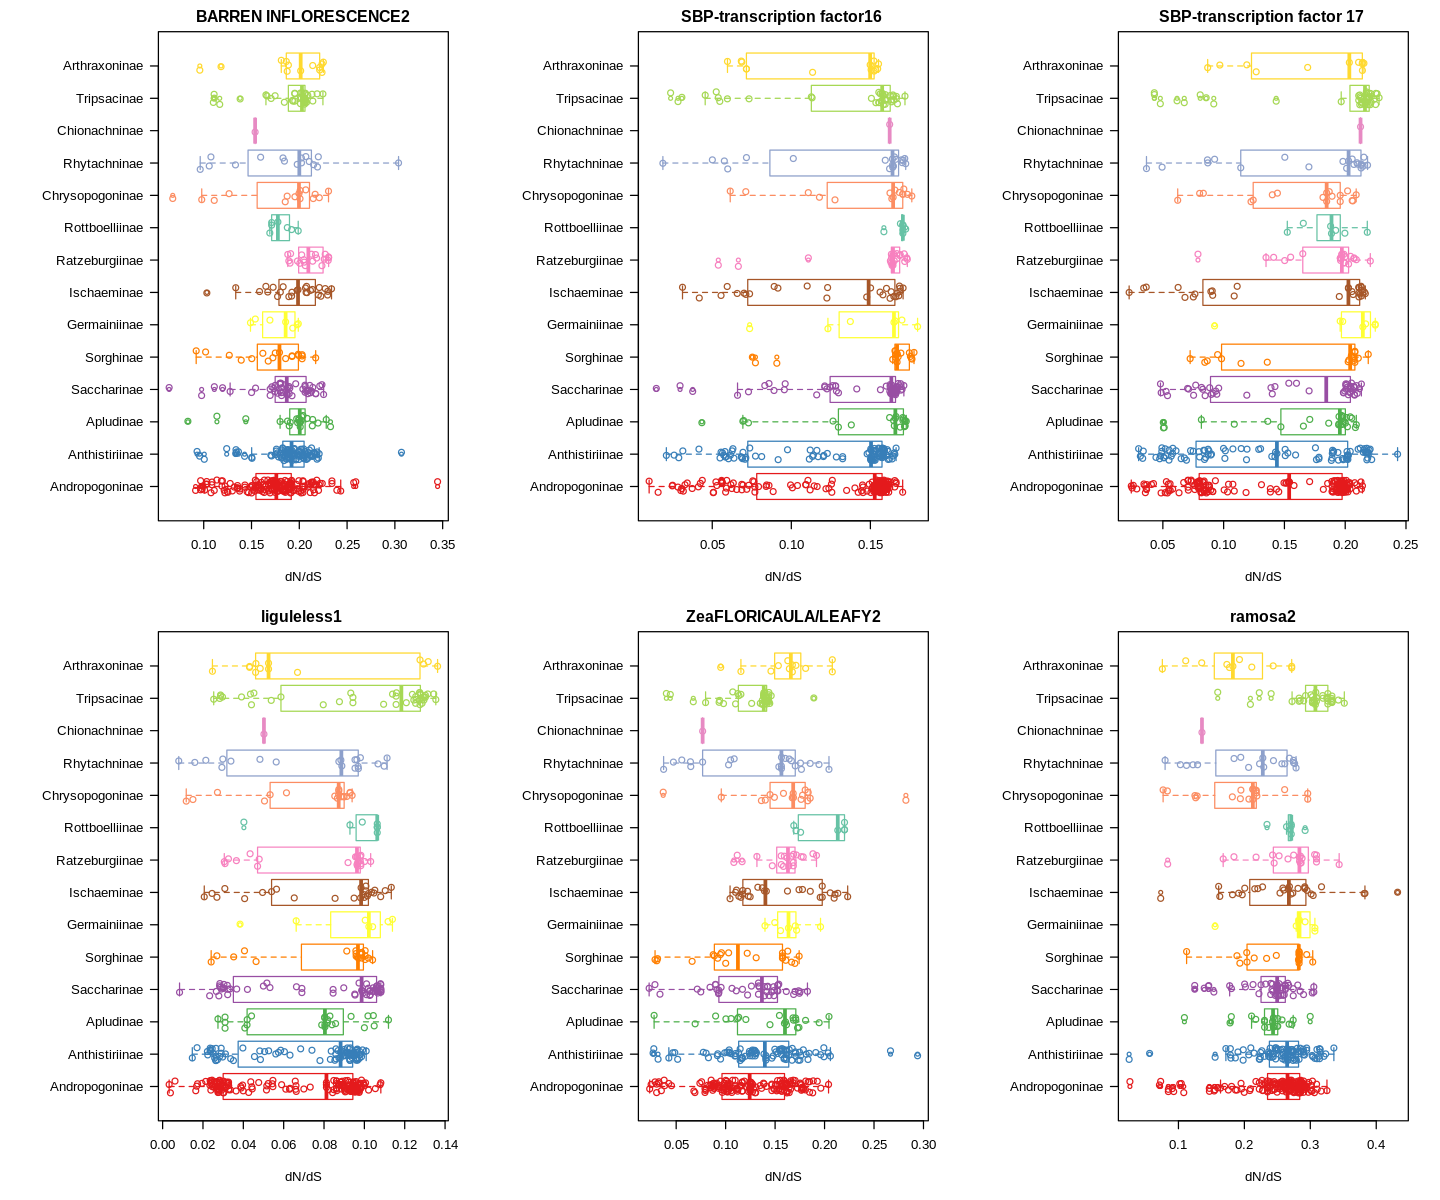

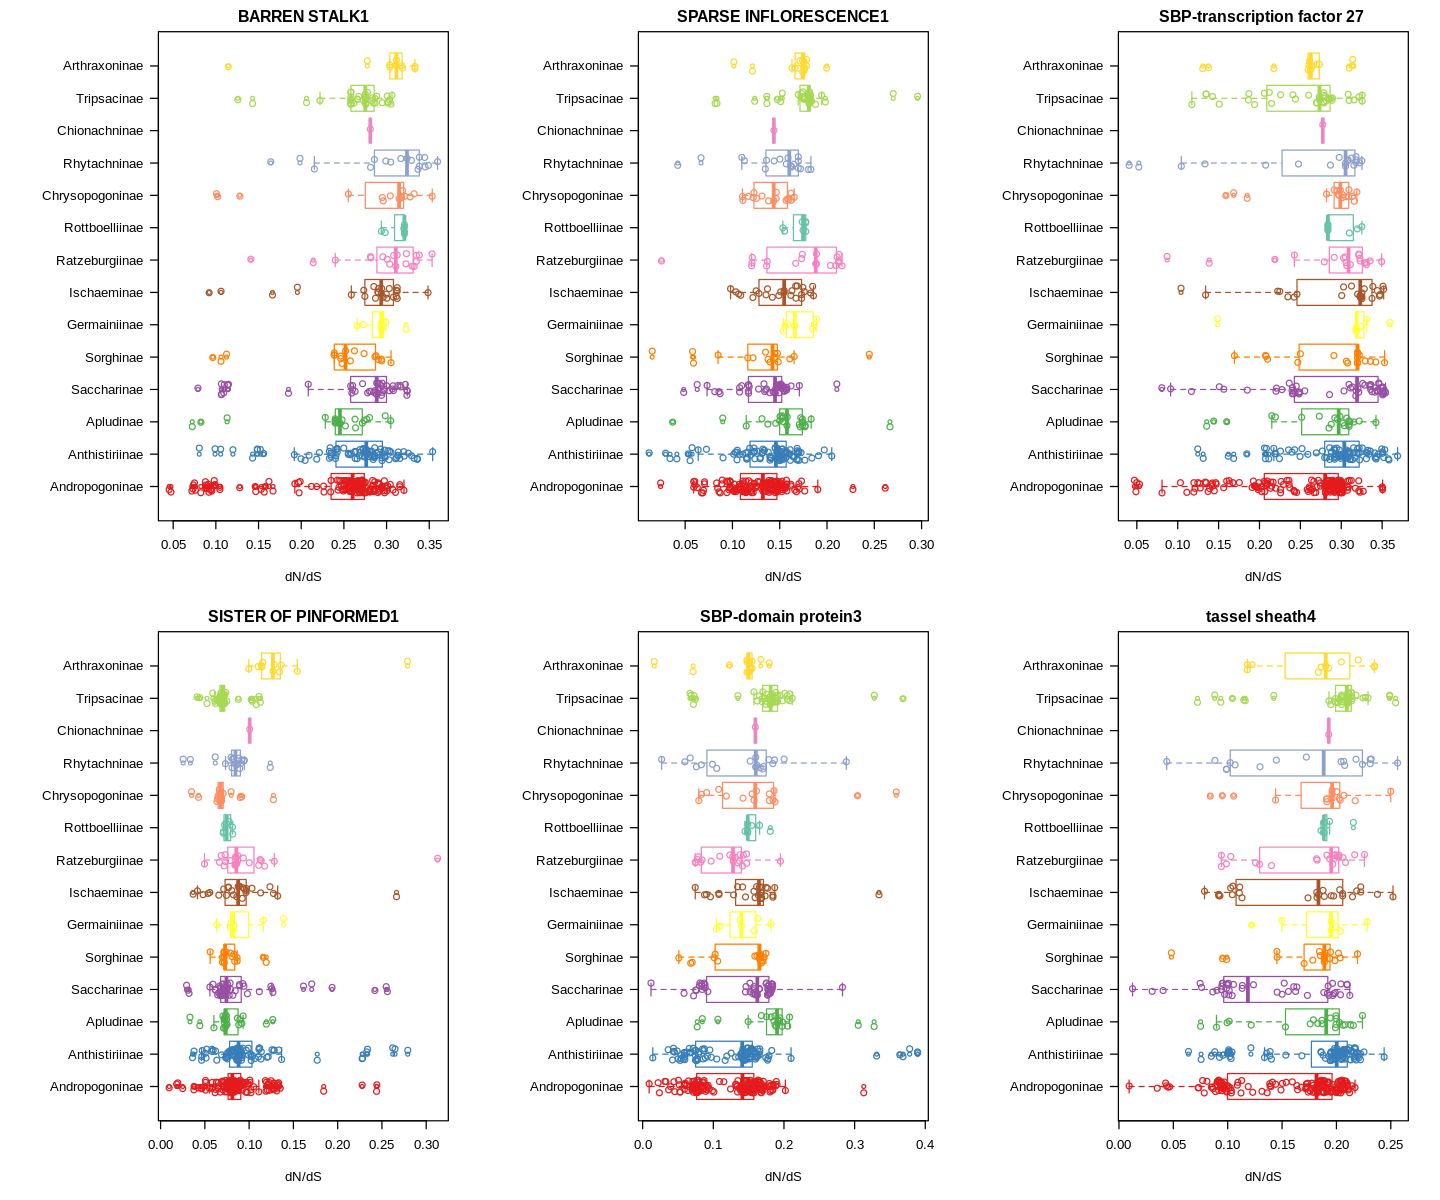

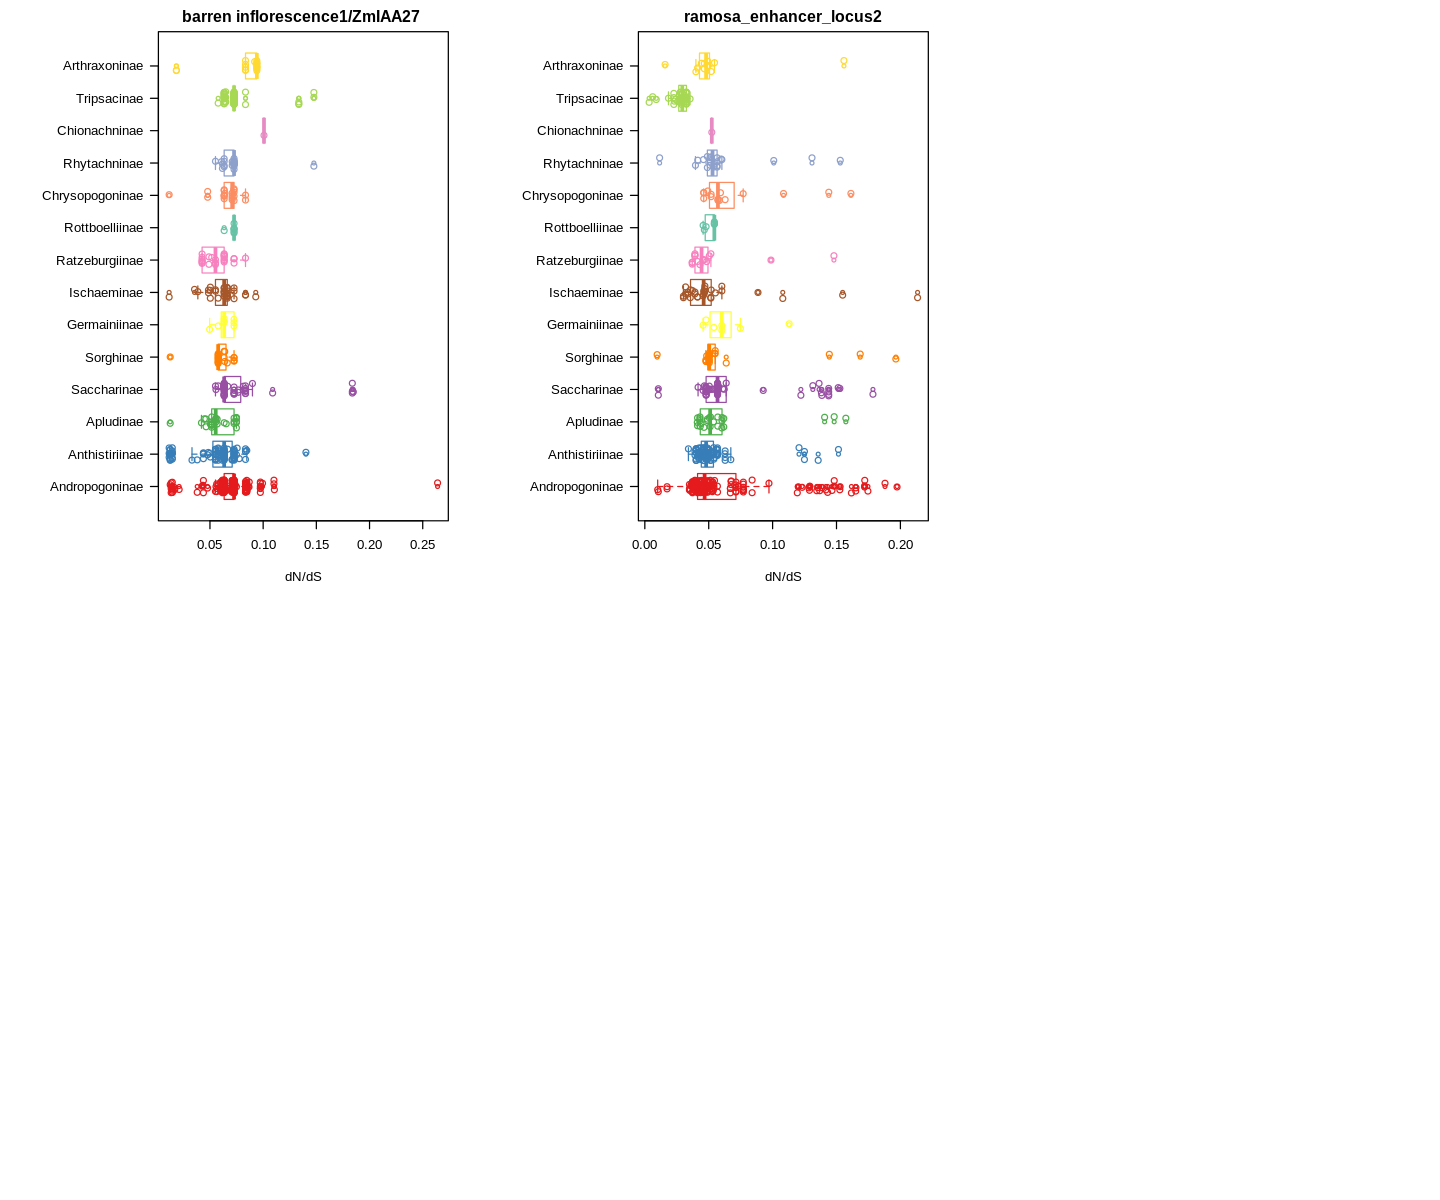

In [159]:
options(repr.plot.width=12, repr.plot.height=10)
par(mar=c(5,10,2,2),mfrow = c(2,3))
for(i in 1:nrow(tobyGeneMerged)){
    tmpSubset = testData_merged[testData_merged$OG%in%tobyGeneMerged[i,3],]
    tmpSubset = merge(tmpSubset,taxanomicGroup,by = "assemblyID")
    tmpSubset = tmpSubset[tmpSubset$tribe== "Andropogoneae",]
    if (anova(lm(tmpSubset$dn.ds~factor(tmpSubset$subtribe,levels = andro_subtribe_levels)))[1,5]>0.05/36) next
    boxplot(tmpSubset$dn.ds~factor(tmpSubset$subtribe,levels = andro_subtribe_levels),
            horizontal = T,las = 1,ylab = "",xlab = "dN/dS",border = mycol,col = NA,main = tobyGeneMerged[i,5])
    points(tmpSubset$dn.ds,as.numeric(factor(tmpSubset$subtribe,levels = andro_subtribe_levels))+runif(nrow(tmpSubset),-.2,.2),
           col = mycol[factor(tmpSubset$subtribe,levels = andro_subtribe_levels)])
}

[1] 0.002986525

In [158]:
0.05/36

[1] 0.001388889

Warning message:
“Removed 43 rows containing non-finite outside the scale range (`stat_ydensity()`).”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”
Warning message:
“Groups with fewer than two datapoints have been dropped.
ℹ Set `drop = FALSE` to consider such groups for position adjustment purposes.”


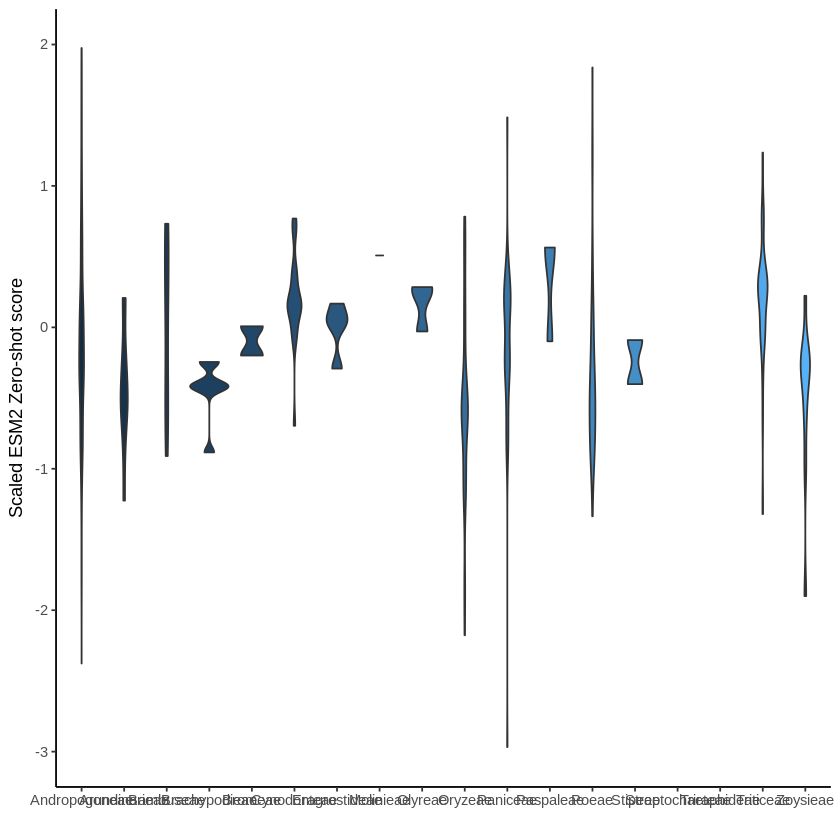

In [112]:
ggplot(tmpSubset, aes(y = scaledScore, x = tribe,fill = ..x..)) +
  geom_violin() + 
    ylab("Scaled ESM2 Zero-shot score") +
  xlab("") +
  ylim(c(-3,2)) +
  theme_classic() +
  theme(
    legend.position = "none",
    panel.spacing = unit(0.1, "lines"),
    strip.text.x = element_text(size = 8)
  )

In [99]:
gc()

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,22769726,1216.1,40653372,2171.2,36107601,1928.4
Vcells,12452241881,95003.1,19170107420,146256.4,18627375004,142115.6
